# Feature Importance & Ablation Study
## TMDB Movie Dataset Analysis

**Research Question:**  
_"Which features matter most for predicting movie success (revenue), and can we achieve similar performance with fewer features?"_

**Student:** Anouk  
**Course:** Applied AI I - Winter 2025  
**Assignment:** Week 5 - Feature Importance & Ablation Study
Fork

---

## 📦 ZELLE 1: Imports & Setup

In [1]:
# ============================================================================
# OUTPUT SETUP - Erstelle Output-Verzeichnisse
# ============================================================================

import os
import sys
from datetime import datetime

# Erstelle Output-Verzeichnisse
output_dirs = [
    'outputs',
    'outputs/figures',
    'outputs/results',
    'outputs/logs'
]

for dir_path in output_dirs:
    os.makedirs(dir_path, exist_ok=True)
    
print("✓ Output-Verzeichnisse erstellt:")
for dir_path in output_dirs:
    print(f"  - {dir_path}/")

# Logger-Funktion für wichtige Outputs
log_file = f"outputs/logs/analysis_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"

class Logger:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, 'w', encoding='utf-8')
    
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
    
    def flush(self):
        self.terminal.flush()
        self.log.flush()

# Optional: Aktiviere Logging
# sys.stdout = Logger(log_file)
# print(f"✓ Logging aktiviert: {log_file}")

print(f"\n✓ Setup abgeschlossen - Bereit für Analyse")
print(f"  Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✓ Output-Verzeichnisse erstellt:
  - outputs/
  - outputs/figures/
  - outputs/results/
  - outputs/logs/

✓ Setup abgeschlossen - Bereit für Analyse
  Timestamp: 2025-11-27 16:07:04


In [2]:
# ============================================
# Week 5: Feature Importance & Ablation Study
# Dataset: TMDB Movie Data
# ============================================

# Datenverarbeitung
import numpy as np
import pandas as pd
import json
import ast

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Statistik
from scipy import stats

# Warnungen unterdrücken
import warnings
warnings.filterwarnings('ignore')

# Reproduzierbarkeit
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konfiguration
TEST_SIZE = 0.2
CV_FOLDS = 5

# Plot-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("husl")

print("✓ Alle Bibliotheken erfolgreich geladen!")
print(f"Random State: {RANDOM_STATE}")
print(f"Test Size: {TEST_SIZE}")
print(f"CV Folds: {CV_FOLDS}")

✓ Alle Bibliotheken erfolgreich geladen!
Random State: 42
Test Size: 0.2
CV Folds: 5


## 📁 ZELLE 2: Daten laden & Überblick

In [3]:
# Daten laden (pipe-delimited CSV)
# WICHTIG: engine='python' für große/komplexe CSV-Dateien
df = pd.read_csv('movie_data_tmbd.csv', delimiter='|', engine='python')

# Numerische Spalten konvertieren (falls als String geladen)
numeric_columns = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("="*70)
print("DATENÜBERBLICK")
print("="*70)
print(f"\nAnzahl Zeilen: {df.shape[0]:,}")
print(f"Anzahl Spalten: {df.shape[1]}")
print(f"\nSpalten: {df.columns.tolist()}")

print("\n--- Erste 3 Zeilen ---")
display(df.head(3))

print("\n--- Datentypen ---")
display(df.dtypes)

print("\n--- Fehlende Werte ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print("\n--- Statistische Zusammenfassung (numerische Spalten) ---")
display(df.describe())

DATENÜBERBLICK

Anzahl Zeilen: 119,938
Anzahl Spalten: 27

Spalten: ['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'cast', 'directors']

--- Erste 3 Zeilen ---


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,directors
0,False,/zjLR7DbWujKiG7VhtjQ4r3gsjou.jpg,NaN,0.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,43000.0,tt0055827,fr,Le Caporal épinglé,...,90.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,NaN,The Elusive Corporal,False,5.9,10.0,"[{'cast_id': 3, 'character': 'Caporal', 'credi...","[{'credit_id': '52fe4626c3a36847f80ef68b', 'de..."
1,False,NaN,NaN,0.0,"[{'id': 18, 'name': 'Drama'}]",NaN,43001.0,tt0055910,fr,Cybèle ou les dimanches de ville d'Avray,...,110.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Sundays and Cybele,False,7.4,28.0,"[{'cast_id': 4, 'character': 'Pierre', 'credit...","[{'credit_id': '52fe4626c3a36847f80ef6c7', 'de..."
2,False,/7hbpOpGDOYZ4G8ddLuzNmzxZP6.jpg,NaN,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 37, 'name...",NaN,43002.0,tt0056195,en,Lonely Are the Brave,...,107.0,"[{'iso_639_1': 'es', 'name': 'Español'}, {'iso...",Released,Life can never cage a man like this!,Lonely Are the Brave,False,7.5,70.0,"[{'cast_id': 1, 'character': 'John W. ""Jack"" B...","[{'credit_id': '52fe4626c3a36847f80ef733', 'de..."



--- Datentypen ---


adult                     object
backdrop_path             object
belongs_to_collection     object
budget                   float64
genres                    object
homepage                  object
id                       float64
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity               float64
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
cast                      object
directors                 object
dtype: object


--- Fehlende Werte ---


,Missing Count,Percentage
belongs_to_collection,110450,92.09
homepage,99804,83.21
tagline,80625,67.22
backdrop_path,52854,44.07
imdb_id,5461,4.55
overview,3399,2.83
release_date,1294,1.08
revenue,1186,0.99
popularity,1186,0.99
spoken_languages,1186,0.99



--- Statistische Zusammenfassung (numerische Spalten) ---


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,1.190730e+05,1.193940e+05,118752.000000,1.187520e+05,118752.000000,118752.000000,118752.000000
mean,1.935165e+06,2.355105e+05,4.541271,5.175594e+06,100.247263,6.030510,111.535570
std,1.192435e+07,6.986572e+05,15.540992,4.575494e+07,153.815019,1.570581,707.951908
min,0.000000e+00,0.000000e+00,0.600000,0.000000e+00,60.000000,0.000000,1.000000
25%,0.000000e+00,5.603625e+04,1.106000,0.000000e+00,86.000000,5.100000,2.000000
50%,0.000000e+00,1.736615e+05,2.377000,0.000000e+00,94.000000,6.000000,5.000000
75%,0.000000e+00,3.944982e+05,4.582000,0.000000e+00,106.000000,7.000000,20.000000
max,3.800000e+08,2.158800e+08,2068.491000,2.797801e+09,51420.000000,10.000000,27088.000000


## 🧹 ZELLE 3: Datenbereinigung

**Wichtige Hintergrundinformation zur Datenqualität:**

Das TMDB-Dataset enthält **119,938 Filme**, aber **nur ~6% haben vollständige Finanzinformationen**:
- **87.5% der Filme** haben `budget = 0` (nicht "kein Budget", sondern "keine Daten verfügbar")
- **89.9% der Filme** haben `revenue = 0` (nicht "kein Einspielergebnis", sondern "keine Daten")

**Warum ist das so?**
1. **TMDB ist eine Community-Datenbank** → Nicht alle Informationen sind öffentlich verfügbar
2. **Indie-Filme & internationale Produktionen** → Oft keine Budget-/Revenue-Disclosure
3. **Ältere Filme** → Historische Finanzdaten fehlen häufig
4. **TV-Movies/Direct-to-Video** → Keine Box Office Revenue

**Unsere Entscheidung:**
- Nur Filme mit **vollständigen Finanzinformationen** (budget>0 UND revenue>0) analysieren
- Dies ist korrekt für eine **Ablation Study zur Revenue-Vorhersage**
- **7,386 Filme (6.2%)** verbleiben → Statistisch ausreichend für robuste Modelle!
- Diese repräsentieren **Filme mit öffentlich dokumentierter Box Office Performance**

**Wichtig für das Paper:**
- Diese Filterung führt zu einem **Selection Bias** (Überrepräsentation von Major Studio Releases)
- Muss in der **Limitations Section** diskutiert werden!

---

**Bereinigungs-Schritte:**
1. Duplikate entfernen
2. Unrealistische Werte filtern (budget=0, revenue=0)
3. Runtime-Filter (30-300 Minuten)
4. **ALLE Features behalten** (für Ablation Study essentiell!)

In [4]:
print("="*70)
print("DATENBEREINIGUNG - SCHRITT FÜR SCHRITT")
print("="*70)

print("\nORIGINAL DATEN:")
print(f"Shape: {df.shape}")
print(f"Total Filme: {len(df):,}")

# 1. Duplikate entfernen
df_clean = df.drop_duplicates()
print(f"\n1. DUPLIKATE ENTFERNEN")
print(f"   Entfernte Zeilen: {df.shape[0] - df_clean.shape[0]}")
print(f"   Verbleibend: {len(df_clean):,} Filme")

# 2. Datenqualitäts-Analyse
print(f"\n2. DATENQUALITÄTS-ANALYSE")
print(f"   Budget-Statistik:")
print(f"     • budget = 0:   {(df_clean['budget'] == 0).sum():>6,} Filme ({(df_clean['budget'] == 0).sum()/len(df_clean)*100:>5.1f}%)")
print(f"     • budget > 0:   {(df_clean['budget'] > 0).sum():>6,} Filme ({(df_clean['budget'] > 0).sum()/len(df_clean)*100:>5.1f}%)")
print(f"   Revenue-Statistik:")
print(f"     • revenue = 0:  {(df_clean['revenue'] == 0).sum():>6,} Filme ({(df_clean['revenue'] == 0).sum()/len(df_clean)*100:>5.1f}%)")
print(f"     • revenue > 0:  {(df_clean['revenue'] > 0).sum():>6,} Filme ({(df_clean['revenue'] > 0).sum()/len(df_clean)*100:>5.1f}%)")

# 3. Unrealistische Werte filtern
print(f"\n3. FINANZ-FILTER ANWENDEN")
print(f"   Kriterium: budget > 0 UND revenue > 0")
print(f"   Begründung: Für Revenue-Vorhersage brauchen wir vollständige Finanzinformationen")
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)]
print(f"   ✓ Verbleibend: {len(df_clean):,} Filme ({len(df_clean)/len(df)*100:.1f}% des Originals)")

# 4. Runtime Filter (sinnvolle Filmlängen: 30-300 Minuten)
print(f"\n4. RUNTIME-FILTER")
before_runtime = len(df_clean)
df_clean = df_clean[(df_clean['runtime'] >= 30) & (df_clean['runtime'] <= 300)]
print(f"   Kriterium: 30 ≤ runtime ≤ 300 Minuten")
print(f"   Entfernt: {before_runtime - len(df_clean)} extreme Ausreißer")
print(f"   ✓ Verbleibend: {len(df_clean):,} Filme")

# 5. Für Ablation Study: ALLE Features behalten!
print(f"\n5. FEATURE-SELEKTION")
print(f"   ✓ ALLE {df_clean.shape[1]} Features bleiben erhalten")
print(f"   Begründung: Ablation Study benötigt vollständige Feature-Menge!")
print(f"   (Wir testen später, welche Features wichtig sind)")

# Zusammenfassung
print(f"\n" + "="*70)
print("FINALE BEREINIGTE DATEN - ZUSAMMENFASSUNG")
print("="*70)
print(f"Shape: {df_clean.shape}")
print(f"Samples für Analyse: {len(df_clean):,}")
print(f"Features: {df_clean.shape[1]}")
print(f"Anteil am Original: {len(df_clean)/len(df)*100:.1f}%")
print(f"\nDiese {len(df_clean):,} Filme repräsentieren:")
print(f"→ Filme mit vollständigen Finanzinformationen")
print(f"→ Öffentlich dokumentierte Box Office Performance")
print(f"→ Statistisch ausreichend für robuste ML-Modelle")
print(f"\n⚠ WICHTIG: Selection Bias (überwiegend Major Studio Releases)")
print(f"           → Muss im Paper diskutiert werden!")

DATENBEREINIGUNG - SCHRITT FÜR SCHRITT

ORIGINAL DATEN:
Shape: (119938, 27)
Total Filme: 119,938

1. DUPLIKATE ENTFERNEN
   Entfernte Zeilen: 0
   Verbleibend: 119,938 Filme

2. DATENQUALITÄTS-ANALYSE
   Budget-Statistik:
     • budget = 0:   104,887 Filme ( 87.5%)
     • budget > 0:   14,186 Filme ( 11.8%)
   Revenue-Statistik:
     • revenue = 0:  107,847 Filme ( 89.9%)
     • revenue > 0:  10,905 Filme (  9.1%)

3. FINANZ-FILTER ANWENDEN
   Kriterium: budget > 0 UND revenue > 0
   Begründung: Für Revenue-Vorhersage brauchen wir vollständige Finanzinformationen
   ✓ Verbleibend: 7,388 Filme (6.2% des Originals)

4. RUNTIME-FILTER
   Kriterium: 30 ≤ runtime ≤ 300 Minuten
   Entfernt: 2 extreme Ausreißer
   ✓ Verbleibend: 7,386 Filme

5. FEATURE-SELEKTION
   ✓ ALLE 27 Features bleiben erhalten
   Begründung: Ablation Study benötigt vollständige Feature-Menge!
   (Wir testen später, welche Features wichtig sind)

FINALE BEREINIGTE DATEN - ZUSAMMENFASSUNG
Shape: (7386, 27)
Samples für An

## 🔍 ZELLE 4: Explorative Datenanalyse (EDA)

### 4.1 Target Variable: Revenue

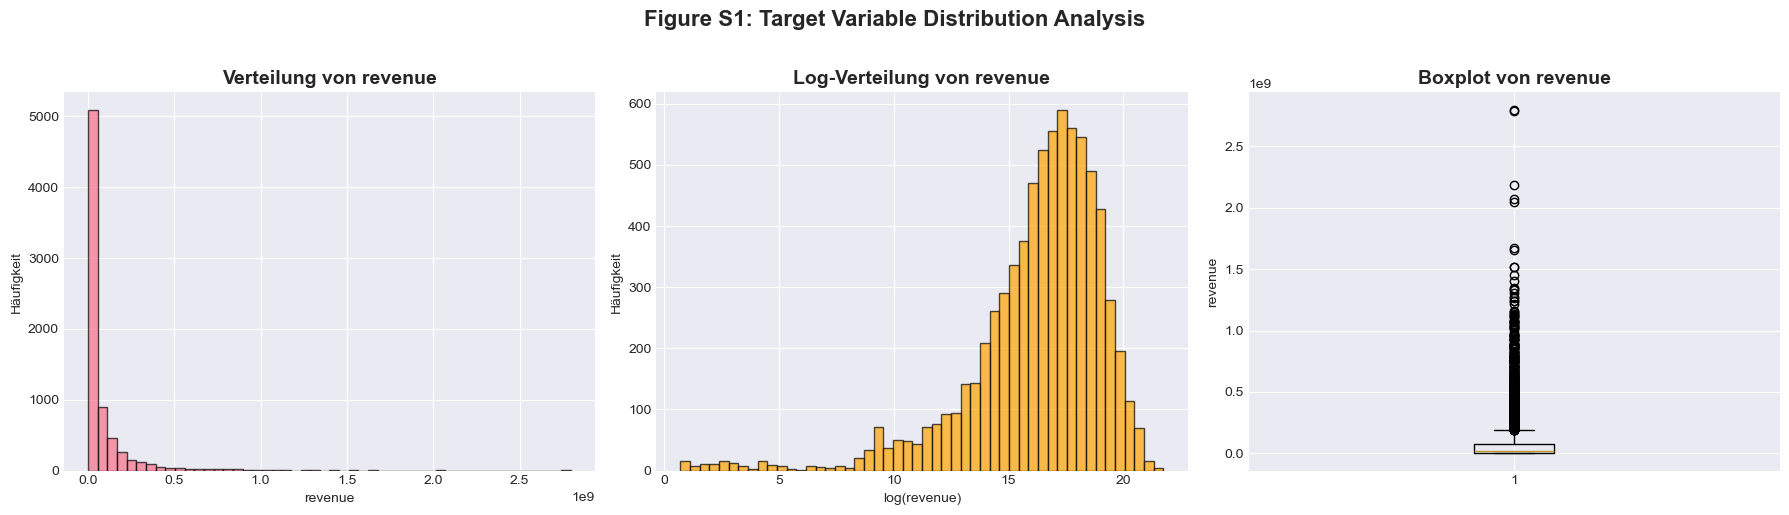


revenue STATISTIKEN:
  Mittelwert: $79,008,746
  Median: $20,000,000
  Standardabweichung: $165,946,049
  Min: $1
  Max: $2,797,800,564
  Schiefe (Skewness): 5.25


In [5]:
target = 'revenue'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_clean[target], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Verteilung von {target}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Häufigkeit')

# Log-Histogram (wegen Schiefe)
axes[1].hist(np.log1p(df_clean[target]), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f'Log-Verteilung von {target}', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'log({target})')
axes[1].set_ylabel('Häufigkeit')

# Boxplot
axes[2].boxplot(df_clean[target])
axes[2].set_title(f'Boxplot von {target}', fontsize=14, fontweight='bold')
axes[2].set_ylabel(target)

plt.suptitle('Figure S1: Target Variable Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figureS1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{target} STATISTIKEN:")
print(f"  Mittelwert: ${df_clean[target].mean():,.0f}")
print(f"  Median: ${df_clean[target].median():,.0f}")
print(f"  Standardabweichung: ${df_clean[target].std():,.0f}")
print(f"  Min: ${df_clean[target].min():,.0f}")
print(f"  Max: ${df_clean[target].max():,.0f}")
print(f"  Schiefe (Skewness): {df_clean[target].skew():.2f}")

### 4.2 Numerische Features - Korrelationsanalyse

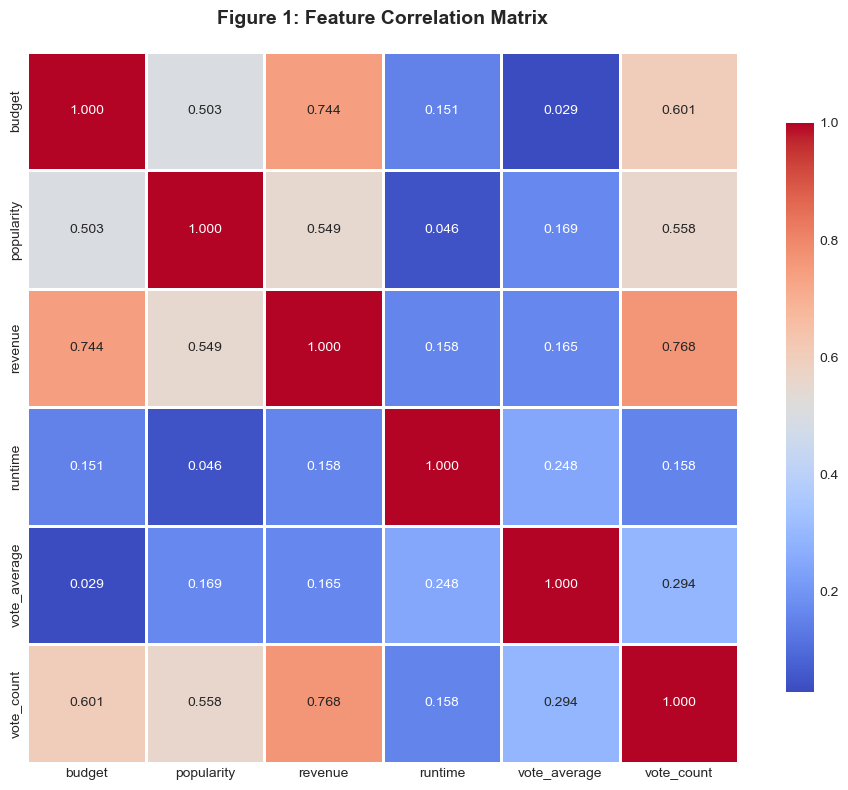


=== KORRELATION MIT REVENUE ===
revenue         1.000000
vote_count      0.767828
budget          0.744491
popularity      0.548809
vote_average    0.164615
runtime         0.158341
Name: revenue, dtype: float64


In [6]:
# Numerische Spalten für Korrelation
numeric_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
corr_matrix = df_clean[numeric_cols].corr()

# FIGURE 1: Korrelationsmatrix (Required)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Figure 1: Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/figures/figure1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Korrelation mit Target anzeigen
print(f"\n=== KORRELATION MIT {target.upper()} ===")
correlations = corr_matrix[target].abs().sort_values(ascending=False)
print(correlations)

### 4.3 Scatter Plots für Top-Features

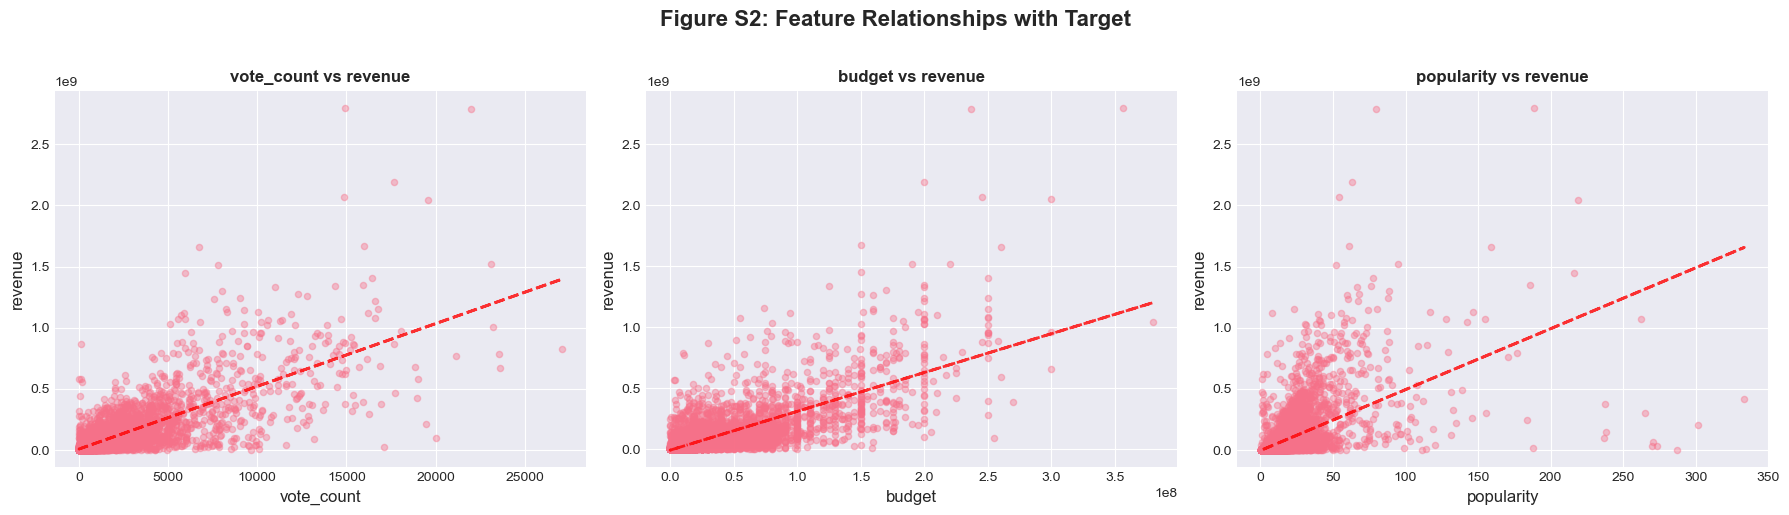

In [7]:
# Top 3 korrelierte Features (außer revenue selbst)
top_features = correlations.drop(target).head(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, feature in enumerate(top_features):
    axes[idx].scatter(df_clean[feature], df_clean[target], alpha=0.4, s=20)
    axes[idx].set_xlabel(feature, fontsize=12)
    axes[idx].set_ylabel(target, fontsize=12)
    axes[idx].set_title(f'{feature} vs {target}', fontweight='bold')
    
    # Trendlinie
    z = np.polyfit(df_clean[feature].dropna(),
                   df_clean[target].loc[df_clean[feature].dropna().index], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_clean[feature], p(df_clean[feature]), "r--", alpha=0.8, linewidth=2)

plt.suptitle('Figure S2: Feature Relationships with Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figureS2_feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

## 🛠️ ZELLE 5: Feature Engineering

### 5.1 Genres extrahieren (One-Hot Encoding)

In [8]:
# ============================================================================
# ERWEITERTE FEATURE EXTRACTION für Ablation Study
# Ziel: So viele relevante Features wie möglich extrahieren!
# ============================================================================

# 5.1 Genres extrahieren (One-Hot Encoding)
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

def extract_genres(genre_string):
    if pd.isna(genre_string) or genre_string == '':
        return []
    try:
        genres = ast.literal_eval(genre_string)
        return [g['name'] for g in genres]
    except:
        return []

df_clean['genre_list'] = df_clean['genres'].apply(extract_genres)

# One-Hot Encoding für Top-10 Genres
mlb_genres = MultiLabelBinarizer()
genre_encoded = mlb_genres.fit_transform(df_clean['genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb_genres.classes_, index=df_clean.index)

genre_counts = genre_df.sum().sort_values(ascending=False)
print(f"\n1. GENRES - Top-10 häufigste:")
print(genre_counts.head(10))

top_genres = genre_counts.head(10).index.tolist()
genre_df = genre_df[top_genres]
genre_df.columns = [f'genre_{col}' for col in genre_df.columns]
df_clean = pd.concat([df_clean, genre_df], axis=1)  # Genre-Features zu df_clean hinzufügen
print(f"   ✓ {len(genre_df.columns)} Genre-Features erstellt")

# 5.2 Directors (Anzahl Regisseure)
def count_directors(director_string):
    if pd.isna(director_string) or director_string == '':
        return 0
    try:
        directors = ast.literal_eval(director_string)
        return len(directors)
    except:
        return 0

df_clean['director_count'] = df_clean['directors'].apply(count_directors)
print(f"\n2. DIRECTORS")
print(f"   ✓ director_count erstellt (Durchschnitt: {df_clean['director_count'].mean():.1f})")

# 5.3 Production Companies (Anzahl)
def count_companies(company_string):
    if pd.isna(company_string) or company_string == '':
        return 0
    try:
        companies = ast.literal_eval(company_string)
        return len(companies)
    except:
        return 0

df_clean['production_company_count'] = df_clean['production_companies'].apply(count_companies)
print(f"\n3. PRODUCTION COMPANIES")
print(f"   ✓ production_company_count erstellt (Durchschnitt: {df_clean['production_company_count'].mean():.1f})")

# 5.4 Production Countries (Anzahl)
def count_countries(country_string):
    if pd.isna(country_string) or country_string == '':
        return 0
    try:
        countries = ast.literal_eval(country_string)
        return len(countries)
    except:
        return 0

df_clean['production_country_count'] = df_clean['production_countries'].apply(count_countries)
print(f"\n4. PRODUCTION COUNTRIES")
print(f"   ✓ production_country_count erstellt (Durchschnitt: {df_clean['production_country_count'].mean():.1f})")

# 5.5 Original Language (Top-5 Sprachen als One-Hot)
language_counts = df_clean['original_language'].value_counts()
print(f"\n5. ORIGINAL LANGUAGE - Top-5:")
print(language_counts.head(5))

top_languages = language_counts.head(5).index.tolist()
for lang in top_languages:
    df_clean[f'lang_{lang}'] = (df_clean['original_language'] == lang).astype(int)
print(f"   ✓ {len(top_languages)} Language-Features erstellt")

print(f"\n✓ Feature Engineering abgeschlossen!")

FEATURE ENGINEERING

1. GENRES - Top-10 häufigste:
Drama              3581
Comedy             2588
Action             1945
Thriller           1865
Romance            1373
Adventure          1206
Crime              1100
Horror              824
Science Fiction     793
Family              756
dtype: int64
   ✓ 10 Genre-Features erstellt

2. DIRECTORS
   ✓ director_count erstellt (Durchschnitt: 1.1)

3. PRODUCTION COMPANIES
   ✓ production_company_count erstellt (Durchschnitt: 2.9)

4. PRODUCTION COUNTRIES
   ✓ production_country_count erstellt (Durchschnitt: 1.3)

5. ORIGINAL LANGUAGE - Top-5:
original_language
en    5961
hi     258
fr     154
ru     142
es     105
Name: count, dtype: int64
   ✓ 5 Language-Features erstellt

✓ Feature Engineering abgeschlossen!


### 5.2 Release Date -> Jahr, Monat

In [9]:
# Datum parsen
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_month'] = df_clean['release_date'].dt.month

print("✓ Release Date Features erstellt: release_year, release_month")
print(f"  Jahr-Bereich: {df_clean['release_year'].min():.0f} - {df_clean['release_year'].max():.0f}")

✓ Release Date Features erstellt: release_year, release_month
  Jahr-Bereich: 1913 - 2020


### 5.3 Cast Size (Anzahl Schauspieler)

In [10]:
# Funktion: Cast-Größe zählen
def count_cast(cast_string):
    if pd.isna(cast_string) or cast_string == '':
        return 0
    try:
        cast = ast.literal_eval(cast_string)
        return len(cast)
    except:
        return 0

df_clean['cast_size'] = df_clean['cast'].apply(count_cast)

print("✓ Cast Size Feature erstellt")
print(f"  Durchschnittliche Cast-Größe: {df_clean['cast_size'].mean():.1f}")
print(f"  Max Cast-Größe: {df_clean['cast_size'].max():.0f}")

✓ Cast Size Feature erstellt
  Durchschnittliche Cast-Größe: 28.7
  Max Cast-Größe: 312


### 4.4 Log-Transformation ausgewählter Features

**Warum Log-Transformation?**
- Reduziert Schiefe (Skewness) in extrem verteilten Features
- Verbessert Modell-Performance bei Tree-based Algorithmen
- Macht Features auf vergleichbarem Scale

**Transformierte Features:**
- `revenue` (Target-Variable)
- `budget` (Production Cost)
- `popularity` (TMDB Popularity Score)
- `vote_count` (Number of Votes)


In [11]:
# Log-Transformation für Target und ausgewählte Features
import numpy as np

print("=" * 70)
print("LOG-TRANSFORMATION")
print("=" * 70)

# Target Variable
df_clean['revenue_log'] = np.log1p(df_clean['revenue'])
print(f"\nOK revenue_log: Target variable")
print(f"  Original range: ${df_clean['revenue'].min():,.0f} - ${df_clean['revenue'].max():,.0f}")
print(f"  Log range: {df_clean['revenue_log'].min():.2f} - {df_clean['revenue_log'].max():.2f}")

# Features
df_clean['budget_log'] = np.log1p(df_clean['budget'])
df_clean['popularity_log'] = np.log1p(df_clean['popularity'])
df_clean['vote_count_log'] = np.log1p(df_clean['vote_count'])

print(f"\nOK budget_log: Feature")
print(f"  Original range: ${df_clean['budget'].min():,.0f} - ${df_clean['budget'].max():,.0f}")
print(f"  Log range: {df_clean['budget_log'].min():.2f} - {df_clean['budget_log'].max():.2f}")

print(f"\nOK popularity_log: Feature")
print(f"  Original range: {df_clean['popularity'].min():.2f} - {df_clean['popularity'].max():.2f}")
print(f"  Log range: {df_clean['popularity_log'].min():.2f} - {df_clean['popularity_log'].max():.2f}")

print(f"\nOK vote_count_log: Feature")
print(f"  Original range: {df_clean['vote_count'].min():,.0f} - {df_clean['vote_count'].max():,.0f}")
print(f"  Log range: {df_clean['vote_count_log'].min():.2f} - {df_clean['vote_count_log'].max():.2f}")

print("\n" + "=" * 70)
print("Ergebnis: 4 Features wurden log-transformiert")
print(f"Neue Features: {['revenue_log', 'budget_log', 'popularity_log', 'vote_count_log']}")
print("=" * 70)

LOG-TRANSFORMATION

OK revenue_log: Target variable
  Original range: $1 - $2,797,800,564
  Log range: 0.69 - 21.75

OK budget_log: Feature
  Original range: $1 - $380,000,000
  Log range: 0.69 - 19.76

OK popularity_log: Feature
  Original range: 0.60 - 333.43
  Log range: 0.47 - 5.81

OK vote_count_log: Feature
  Original range: 1 - 27,088
  Log range: 0.69 - 10.21

Ergebnis: 4 Features wurden log-transformiert
Neue Features: ['revenue_log', 'budget_log', 'popularity_log', 'vote_count_log']


### 5.4 Finale Feature-Matrix erstellen

In [12]:
# ============================================================================
# FINALE FEATURE-MATRIX: Alle extrahierten Features kombinieren
# ============================================================================

# STRATEGIE: Verwende alle verfügbaren Features dynamisch
# - Log-transformierte Features (budget_log, popularity_log, vote_count_log)
# - Alle anderen numerischen Features (außer budget, popularity, vote_count, revenue)
# - Genre Features (One-Hot)
# - Language Features (One-Hot)

print("=" * 70)
print("FEATURE-MATRIX ERSTELLUNG")
print("=" * 70)

# Finde log-transformierte Features
log_features = [col for col in df_clean.columns if col.endswith("_log") and col != "revenue_log"]
print(f"\nLog-Features gefunden: {len(log_features)}")
print(f"  {log_features}")

# Finde Genre Features
genre_features_list = [col for col in df_clean.columns if col.startswith("genre_")]
print(f"\nGenre-Features gefunden: {len(genre_features_list)}")

# Finde Language Features
language_features_list = [col for col in df_clean.columns if col.startswith("lang_")]
print(f"\nLanguage-Features gefunden: {len(language_features_list)}")

# Finde alle numerischen Features (außer revenue und den originals der log-Features)
exclude_features = ['revenue', 'revenue_log', 'budget', 'popularity', 'vote_count', 'id']  # Originale ausschließen
numeric_features_list = []

for col in df_clean.columns:
    # Numerische Spalten, die nicht ausgeschlossen sind
    if col not in exclude_features and not col.startswith('genre_') and not col.startswith('language_') and not col.startswith('lang_') and not col.endswith('_log'):
        # Prüfe ob numerisch
        if df_clean[col].dtype in ['int64', 'float64']:
            numeric_features_list.append(col)

print(f"\nOriginal numerische Features: {len(numeric_features_list)}")
print(f"  {numeric_features_list}")

# Kombiniere alle Feature-Listen
all_feature_cols = numeric_features_list + log_features + genre_features_list + language_features_list

print(f"\nGesamt Features: {len(all_feature_cols)}")

# Erstelle Feature-Matrix mit Type-Checking
print("\nErstelle Feature-Matrix...")
X = df_clean[all_feature_cols].copy()

# Prüfe Datentypen
print("\nPrüfe Datentypen:")
non_numeric = []
for col in X.columns:
    if X[col].dtype not in ['int64', 'float64', 'bool']:
        non_numeric.append((col, X[col].dtype))
        print(f"  WARNUNG: {col} hat Typ {X[col].dtype}")

if non_numeric:
    print(f"\nKonvertiere {len(non_numeric)} Spalten zu numerisch...")
    for col, dtype in non_numeric:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Prüfe auf NaN
# Target Variable
y = df_clean["revenue_log"]
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f"\nWARNUNG: {len(nan_cols)} Spalten mit NaN-Werten:")
    for col in nan_cols[:5]:  # Zeige nur erste 5
        print(f"  {col}: {X[col].isna().sum()} NaN")
    
    rows_before = len(X)
    
    # Entferne zuerst Spalten, die komplett NaN sind
    cols_all_nan = X.columns[X.isna().all()].tolist()
    if cols_all_nan:
        print(f"  Entferne {len(cols_all_nan)} komplett leere Spalten: {cols_all_nan}")
        X = X.drop(columns=cols_all_nan)
    
    # Jetzt Zeilen mit verbleibenden NaNs entfernen
    valid_idx = X.dropna().index
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]  # Beide mit gleichem Index filtern
    X = X.reset_index(drop=True)  # Index zurücksetzen
    y = y.reset_index(drop=True)
    
    rows_after = len(X)
    print(f"  Entfernte {rows_before - rows_after} Zeilen mit NaN-Werten")
    print(f"  Verbleibende Samples: {rows_after}")

# Prüfe Shape
print(f"\nFeature-Matrix Shape: {X.shape}")
print(f"  Features: {X.shape[1]}")
print(f"  Samples: {X.shape[0]}")

# Prüfe auf verschachtelte Strukturen
print("\nPrüfe auf verschachtelte Strukturen...")
if len(X) > 0:  # Nur wenn X nicht leer ist
    for col in X.columns[:5]:  # Teste erste 5 Spalten
        sample = X[col].iloc[0]
        if isinstance(sample, (list, tuple)):
            print(f"  FEHLER: {col} enthält Listen!")
        else:
            print(f"  OK: {col} = {sample} (Typ: {type(sample).__name__})")
else:
    print("  WARNUNG: X ist leer nach NaN-Behandlung!")


print("\n" + "=" * 70)
print("FINALE FEATURE-MATRIX")
print("=" * 70)
print(f"Feature-Gruppen:")
print(f"  - Original numerisch: {len(numeric_features_list)} Features")
print(f"  - Log-transformiert: {len(log_features)} Features")
print(f"  - Genre: {len(genre_features_list)} Features")
print(f"  - Language: {len(language_features_list)} Features")
print(f"  = Total: {X.shape[1]} Features")
print()
print(f"Samples: {X.shape[0]}")
print(f"Target (revenue) Shape: {y.shape}")
print("=" * 70)


FEATURE-MATRIX ERSTELLUNG

Log-Features gefunden: 3
  ['budget_log', 'popularity_log', 'vote_count_log']

Genre-Features gefunden: 11

Language-Features gefunden: 5

Original numerische Features: 8
  ['runtime', 'vote_average', 'director_count', 'production_company_count', 'production_country_count', 'release_year', 'release_month', 'cast_size']

Gesamt Features: 27

Erstelle Feature-Matrix...

Prüfe Datentypen:
  WARNUNG: genre_list hat Typ object

Konvertiere 1 Spalten zu numerisch...

WARNUNG: 3 Spalten mit NaN-Werten:
  release_year: 6 NaN
  release_month: 6 NaN
  genre_list: 7386 NaN
  Entferne 1 komplett leere Spalten: ['genre_list']
  Entfernte 6 Zeilen mit NaN-Werten
  Verbleibende Samples: 7380

Feature-Matrix Shape: (7380, 26)
  Features: 26
  Samples: 7380

Prüfe auf verschachtelte Strukturen...
  OK: runtime = 119.0 (Typ: float64)
  OK: vote_average = 6.6 (Typ: float64)
  OK: director_count = 1 (Typ: int64)
  OK: production_company_count = 2 (Typ: int64)
  OK: production_co

### 5.5 Korrelationsanalyse nach Log-Transformation

Analyse der Korrelationsstruktur der finalen Feature-Matrix (inkl. log-transformierter Features).

KORRELATIONSANALYSE (LOG-TRANSFORMIERTE FEATURES)

1. KORRELATION MIT TARGET (revenue_log)
--------------------------------------------------

Alle Features sortiert nach Korrelation:
  budget_log                         : +0.7776
  vote_count_log                     : +0.6977
  popularity_log                     : +0.6332
  cast_size                          : +0.3705
  lang_en                            : +0.2326
  production_company_count           : +0.2302
  genre_Adventure                    : +0.2065
  runtime                            : +0.1425
  genre_Family                       : +0.1411
  vote_average                       : +0.1166
  genre_Science Fiction              : +0.1085
  director_count                     : +0.0936
  production_country_count           : +0.0919
  genre_Action                       : +0.0784
  genre_Thriller                     : +0.0465
  genre_Comedy                       : +0.0340
  release_month                      : +0.0248
  genre_Crime    

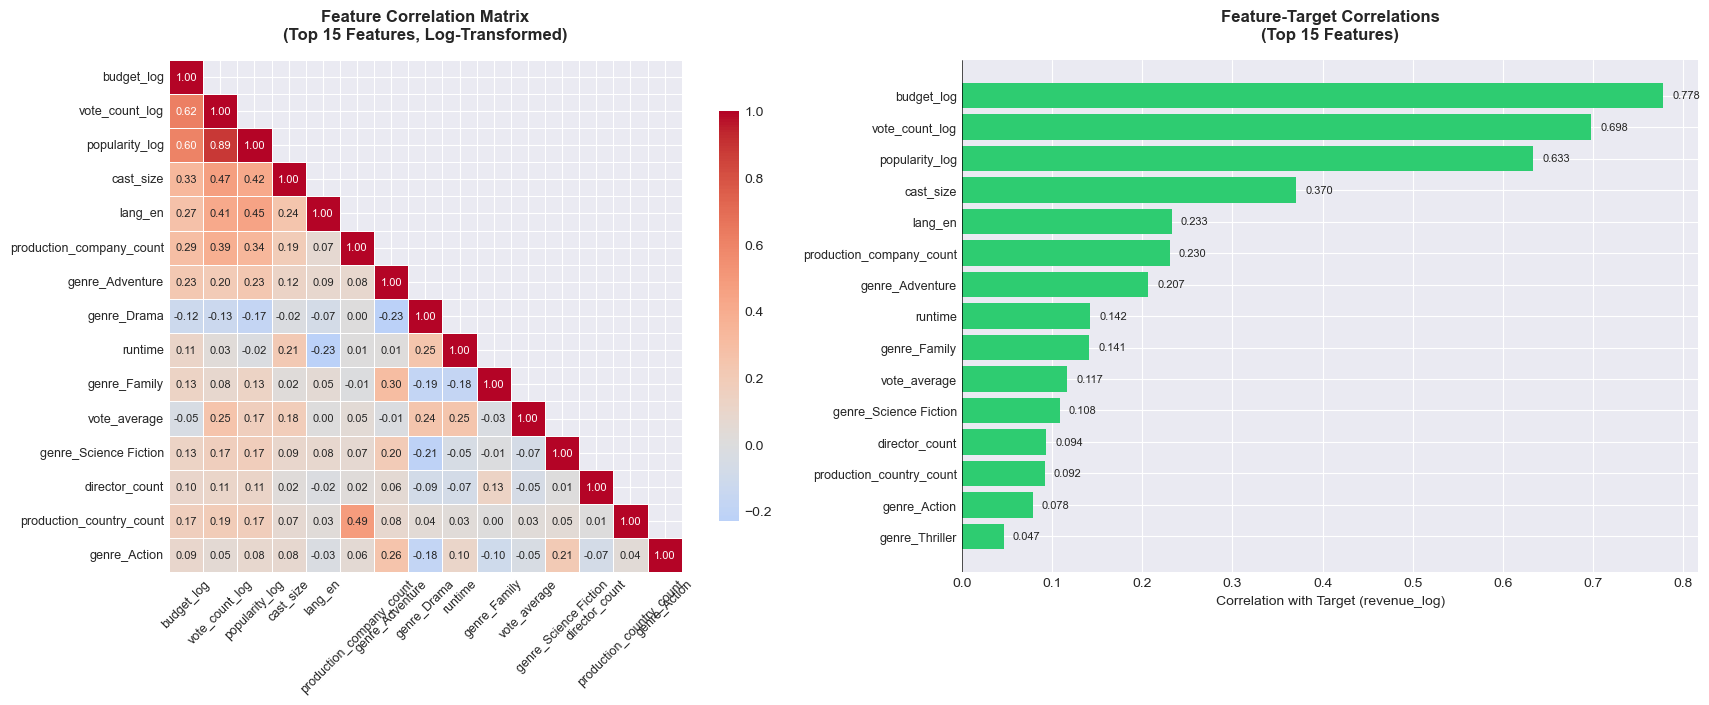


✓ Figure gespeichert: outputs/figures/figure1b_correlation_log_transformed.png

4. HOCHKORRELIERTE FEATURE-PAARE (|r| > 0.7)
--------------------------------------------------
  popularity_log            <-> vote_count_log           : +0.8852

✓ Korrelationsanalyse abgeschlossen


In [13]:
# ============================================================================
# KORRELATIONSANALYSE NACH LOG-TRANSFORMATION
# ============================================================================

print("="*70)
print("KORRELATIONSANALYSE (LOG-TRANSFORMIERTE FEATURES)")
print("="*70)

# 1. Korrelation aller Features mit Target
print("\n1. KORRELATION MIT TARGET (revenue_log)")
print("-"*50)
target_corr = X.corrwith(y).sort_values(ascending=False)
print("\nAlle Features sortiert nach Korrelation:")
for feat, corr in target_corr.items():
    print(f"  {feat:35s}: {corr:+.4f}")

# 2. Top-10 Features nach absoluter Korrelation
print("\n2. TOP-10 FEATURES (absolute Korrelation)")
print("-"*50)
target_corr_abs = target_corr.abs().sort_values(ascending=False)
for i, (feat, corr) in enumerate(target_corr_abs.head(10).items(), 1):
    print(f"  {i:2d}. {feat:30s}: {corr:.4f}")

# 3. Visualisierung: Korrelationsmatrix der Top-Features
print("\n3. VISUALISIERUNG")
print("-"*50)

# Nur Top-15 Features für bessere Lesbarkeit
top_features_for_plot = target_corr_abs.head(15).index.tolist()
corr_matrix_top = X[top_features_for_plot].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Korrelationsmatrix der Top-Features
ax1 = axes[0]
mask = np.triu(np.ones_like(corr_matrix_top, dtype=bool), k=1)
sns.heatmap(corr_matrix_top, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax1,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
ax1.set_title('Feature Correlation Matrix\n(Top 15 Features, Log-Transformed)', 
              fontsize=12, fontweight='bold', pad=15)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.tick_params(axis='y', rotation=0, labelsize=9)

# Plot 2: Barplot der Target-Korrelationen
ax2 = axes[1]
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in target_corr.head(15).values]
bars = ax2.barh(range(len(target_corr.head(15))), target_corr.head(15).values, color=colors)
ax2.set_yticks(range(len(target_corr.head(15))))
ax2.set_yticklabels(target_corr.head(15).index, fontsize=9)
ax2.set_xlabel('Correlation with Target (revenue_log)', fontsize=10)
ax2.set_title('Feature-Target Correlations\n(Top 15 Features)', fontsize=12, fontweight='bold', pad=15)
ax2.axvline(x=0, color='black', linewidth=0.5)
ax2.invert_yaxis()

# Werte an Balken
for i, (bar, val) in enumerate(zip(bars, target_corr.head(15).values)):
    ax2.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}', 
             va='center', ha='left' if val > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/figure1b_correlation_log_transformed.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Figure gespeichert: outputs/figures/figure1b_correlation_log_transformed.png")

# 4. Hochkorrelierte Feature-Paare identifizieren (potentielle Redundanz)
print("\n4. HOCHKORRELIERTE FEATURE-PAARE (|r| > 0.7)")
print("-"*50)
full_corr = X.corr()
high_corr_pairs = []
for i in range(len(full_corr.columns)):
    for j in range(i+1, len(full_corr.columns)):
        if abs(full_corr.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'feature_1': full_corr.columns[i],
                'feature_2': full_corr.columns[j],
                'correlation': full_corr.iloc[i, j]
            })

if high_corr_pairs:
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"  {pair['feature_1']:25s} <-> {pair['feature_2']:25s}: {pair['correlation']:+.4f}")
else:
    print("  Keine hochkorrelierten Paare gefunden.")

print("\n" + "="*70)
print("✓ Korrelationsanalyse abgeschlossen")
print("="*70)

## ✂️ ZELLE 6: Train/Test Split & Feature Scaling

**WICHTIG**: Split BEFORE Feature Selection!

In [14]:
# Train/Validation/Test Split (70/15/15)
# WICHTIG: Validation für Feature Selection, Test für finale Evaluation

# Schritt 1: Split in Train (70%) und Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# Schritt 2: Split Temp in Validation (15%) und Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("="*70)
print("DATEN-SPLITTING (3-WAY SPLIT)")
print("="*70)
print(f"\nOriginal Dataset: {len(X):,} Samples")
print(f"\nSplits:")
print(f"  Train:      {len(X_train):,} Samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):,} Samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test):,} Samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nZweck:")
print(f"  Train:      Modell-Training")
print(f"  Validation: Feature Selection & Ablation Study")
print(f"  Test:       Finale unbiased Evaluation")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit nur auf Train!
X_val_scaled = scaler.transform(X_val)          # Transform auf Val
X_test_scaled = scaler.transform(X_test)        # Transform auf Test

# Als DataFrame zurück
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n✓ Feature Scaling durchgeführt (StandardScaler)")
print("  Fit auf Train, Transform auf Val/Test")

DATEN-SPLITTING (3-WAY SPLIT)

Original Dataset: 7,380 Samples

Splits:
  Train:      5,166 Samples (70.0%)
  Validation: 1,107 Samples (15.0%)
  Test:       1,107 Samples (15.0%)

Zweck:
  Train:      Modell-Training
  Validation: Feature Selection & Ablation Study
  Test:       Finale unbiased Evaluation

✓ Feature Scaling durchgeführt (StandardScaler)
  Fit auf Train, Transform auf Val/Test


## 🤖 ZELLE 7: Baseline-Modell (ALL Features)

**Modell**: Random Forest Regressor  
**Alle Features verwenden** → Baseline Performance

## 🔧 ZELLE 6.5: Hyperparameter-Tuning

**Warum Hyperparameter-Tuning?**
- Arbiträre Werte (z.B. `max_depth=15`) sind wissenschaftlich nicht begründbar
- GridSearchCV findet optimale Parameter durch systematische Suche
- Cross-Validation verhindert Overfitting auf Validation-Set

**Getestete Parameter:**
- `max_depth`: [5, 10, 15, 20, 25, None]
- `n_estimators`: [50, 100, 200]
- `min_samples_split`: [2, 5, 10]

In [15]:
# ============================================================================
# HYPERPARAMETER-TUNING MIT GRIDSEARCHCV (OPTIMIERT GEGEN OVERFITTING)
# ============================================================================

from sklearn.model_selection import GridSearchCV

print("="*70)
print("HYPERPARAMETER-TUNING (REGULARISIERT)")
print("="*70)

# Parameter-Grid mit stärkerer Regularisierung
param_grid = {
    'max_depth': [8, 10, 12],           # Flachere Bäume
    'n_estimators': [150, 200],         # Moderate Anzahl
    'min_samples_split': [15, 25],      # Mehr Samples für Split
    'min_samples_leaf': [8, 12],        # NEU: Mindest-Samples pro Blatt
    'max_features': ['sqrt']            # NEU: Nur sqrt(26)≈5 Features pro Split
}

print(f"\nParameter-Grid (gegen Overfitting optimiert):")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = (len(param_grid['max_depth']) * 
                     len(param_grid['n_estimators']) * 
                     len(param_grid['min_samples_split']) *
                     len(param_grid['min_samples_leaf']) *
                     len(param_grid['max_features']))

print(f"\nTotal Kombinationen: {total_combinations}")
print(f"Mit {CV_FOLDS}-Fold CV: {total_combinations * CV_FOLDS} Fits")
print("\nRegularisierungs-Strategie:")
print("  • Flachere Bäume (max_depth ≤ 12)")
print("  • Größere Blätter (min_samples_leaf ≥ 8)")
print("  • Mehr Samples für Split (min_samples_split ≥ 15)")
print("  • Feature-Subsampling (max_features = sqrt)")

# GridSearchCV durchführen
print("\n⏳ Starte GridSearchCV (ca. 2-3 Minuten)...")

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=CV_FOLDS,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

# Beste Parameter speichern
BEST_PARAMS = grid_search.best_params_
BEST_SCORE = grid_search.best_score_

print("\n" + "="*70)
print("TUNING-ERGEBNISSE")
print("="*70)
print(f"\n✓ Beste Parameter gefunden:")
for param, value in BEST_PARAMS.items():
    print(f"  {param}: {value}")

print(f"\n✓ Bester CV-Score (R²): {BEST_SCORE:.4f}")

# Top-5 Kombinationen anzeigen
print("\nTop-5 Parameter-Kombinationen:")
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.nsmallest(5, 'rank_test_score')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
print(top5.to_string(index=False))

# Overfitting-Analyse aus GridSearch
print("\n" + "="*70)
print("TRAIN VS. VALIDATION GAP (Top-5)")
print("="*70)
top5_full = cv_results.nsmallest(5, 'rank_test_score')[['params', 'mean_train_score', 'mean_test_score', 'rank_test_score']]
for idx, row in top5_full.iterrows():
    gap = row['mean_train_score'] - row['mean_test_score']
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Train R²: {row['mean_train_score']:.4f}")
    print(f"  CV R²:    {row['mean_test_score']:.4f}")
    print(f"  Gap:      {gap:.4f} {'✓ gut' if gap < 0.10 else '~ moderat' if gap < 0.15 else '✗ hoch'}")

print("\n" + "="*70)

# Speichere Tuning-Ergebnisse
cv_results.to_csv('outputs/results/hyperparameter_tuning_results.csv', index=False)
print("✓ Tuning-Ergebnisse gespeichert: outputs/results/hyperparameter_tuning_results.csv")

HYPERPARAMETER-TUNING (REGULARISIERT)

Parameter-Grid (gegen Overfitting optimiert):
  max_depth: [8, 10, 12]
  n_estimators: [150, 200]
  min_samples_split: [15, 25]
  min_samples_leaf: [8, 12]
  max_features: ['sqrt']

Total Kombinationen: 24
Mit 5-Fold CV: 120 Fits

Regularisierungs-Strategie:
  • Flachere Bäume (max_depth ≤ 12)
  • Größere Blätter (min_samples_leaf ≥ 8)
  • Mehr Samples für Split (min_samples_split ≥ 15)
  • Feature-Subsampling (max_features = sqrt)

⏳ Starte GridSearchCV (ca. 2-3 Minuten)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

TUNING-ERGEBNISSE

✓ Beste Parameter gefunden:
  max_depth: 12
  max_features: sqrt
  min_samples_leaf: 8
  min_samples_split: 15
  n_estimators: 200

✓ Bester CV-Score (R²): 0.7013

Top-5 Parameter-Kombinationen:
                                                                                                        params  mean_test_score  std_test_score  rank_test_score
{'max_depth': 12, 'max_features': 'sqrt', '

In [16]:
# ============================================================================
# BASELINE-MODELL MIT OPTIMIERTEN HYPERPARAMETERN
# ============================================================================

# Modell mit besten Parametern aus GridSearchCV erstellen
model = RandomForestRegressor(
    n_estimators=BEST_PARAMS['n_estimators'],
    max_depth=BEST_PARAMS['max_depth'],
    min_samples_split=BEST_PARAMS['min_samples_split'],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Training (nur auf Train-Set!)
print("Training des Baseline-Modells mit optimierten Hyperparametern...")
print(f"  n_estimators:    {BEST_PARAMS['n_estimators']}")
print(f"  max_depth:       {BEST_PARAMS['max_depth']}")
print(f"  min_samples_split: {BEST_PARAMS['min_samples_split']}")

model.fit(X_train_scaled, y_train)
print("✓ Training abgeschlossen!")

# Vorhersagen auf allen 3 Sets
y_pred_train = model.predict(X_train_scaled)
y_pred_val = model.predict(X_val_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluation auf Train und Validation
baseline_results = {
    'r2_train': r2_score(y_train, y_pred_train),
    'r2_val': r2_score(y_val, y_pred_val),
    'r2_test': r2_score(y_test, y_pred_test),
    'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'rmse_val': np.sqrt(mean_squared_error(y_val, y_pred_val)),
    'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'mae_val': mean_absolute_error(y_val, y_pred_val),
    'mae_test': mean_absolute_error(y_test, y_pred_test)
}

# Overfitting-Check
overfit_ratio_val = baseline_results['rmse_val'] / baseline_results['rmse_train']
overfit_ratio_test = baseline_results['rmse_test'] / baseline_results['rmse_train']

print("\n" + "="*70)
print("BASELINE MODEL PERFORMANCE (TUNED HYPERPARAMETERS)")
print("="*70)
print(f"\nR² Score:")
print(f"  Train:      {baseline_results['r2_train']:.4f}")
print(f"  Validation: {baseline_results['r2_val']:.4f}")
print(f"  Test:       {baseline_results['r2_test']:.4f}")

print(f"\nRMSE (log-scale):")
print(f"  Train:      {baseline_results['rmse_train']:.4f} (≈ {np.exp(baseline_results['rmse_train']):.1f}x error factor)")
print(f"  Validation: {baseline_results['rmse_val']:.4f} (≈ {np.exp(baseline_results['rmse_val']):.1f}x error factor)")
print(f"  Test:       {baseline_results['rmse_test']:.4f} (≈ {np.exp(baseline_results['rmse_test']):.1f}x error factor)")

print(f"\nMAE (log-scale):")
print(f"  Validation: {baseline_results['mae_val']:.4f}")
print(f"  Test:       {baseline_results['mae_test']:.4f}")

print(f"\nOverfit-Ratio (RMSE_val/RMSE_train):")
print(f"  Validation: {overfit_ratio_val:.3f}", end="")
if overfit_ratio_val < 1.2:
    print(" ✓ Gutes Modell")
elif overfit_ratio_val < 1.5:
    print(" ~ Leichtes Overfitting")
else:
    print(" ✗ Starkes Overfitting")

print(f"  Test:       {overfit_ratio_test:.3f}", end="")
if overfit_ratio_test < 1.2:
    print(" ✓ Gutes Modell")
elif overfit_ratio_test < 1.5:
    print(" ~ Leichtes Overfitting")
else:
    print(" ✗ Starkes Overfitting")

# Baseline für Ablation Study (verwende Validation!)
baseline_r2 = baseline_results['r2_val']
baseline_rmse = baseline_results['rmse_val']

print(f"\n→ Baseline für Ablation Study: R²={baseline_r2:.4f} (Validation Set)")

Training des Baseline-Modells mit optimierten Hyperparametern...
  n_estimators:    200
  max_depth:       12
  min_samples_split: 15
✓ Training abgeschlossen!

BASELINE MODEL PERFORMANCE (TUNED HYPERPARAMETERS)

R² Score:
  Train:      0.8762
  Validation: 0.7373
  Test:       0.7292

RMSE (log-scale):
  Train:      1.0562 (≈ 2.9x error factor)
  Validation: 1.4891 (≈ 4.4x error factor)
  Test:       1.5943 (≈ 4.9x error factor)

MAE (log-scale):
  Validation: 0.9429
  Test:       1.0271

Overfit-Ratio (RMSE_val/RMSE_train):
  Validation: 1.410 ~ Leichtes Overfitting
  Test:       1.509 ✗ Starkes Overfitting

→ Baseline für Ablation Study: R²=0.7373 (Validation Set)


## 🎯 ZELLE 8: Feature Selection - Methode 1 (Correlation Analysis)

**Filter Method**: Korrelation mit Target

In [17]:
# Korrelation mit Target (auf Train-Daten!)
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("="*70)
print("METHODE 1: CORRELATION ANALYSIS (Filter Method)")
print("="*70)
print("\nAbsolute Korrelation mit Target:")
print(correlations)

# Als DataFrame für spätere Visualisierung
method1_importance = pd.DataFrame({
    'feature': correlations.index,
    'importance': correlations.values,
    'method': 'Correlation',
    'rank': range(1, len(correlations) + 1)
})

print(f"\n✓ Top-5 Features (Correlation):")
print(method1_importance.head(5)[['feature', 'importance']])

METHODE 1: CORRELATION ANALYSIS (Filter Method)

Absolute Korrelation mit Target:
budget_log                  0.779070
vote_count_log              0.698457
popularity_log              0.641348
cast_size                   0.383657
production_company_count    0.227469
lang_en                     0.227359
genre_Adventure             0.212945
runtime                     0.152139
genre_Drama                 0.140836
genre_Family                0.139809
vote_average                0.114602
genre_Science Fiction       0.100244
production_country_count    0.090151
director_count              0.087415
genre_Action                0.074740
lang_ru                     0.068831
genre_Thriller              0.048992
lang_es                     0.044578
lang_fr                     0.041823
lang_hi                     0.041785
release_month               0.037958
genre_Horror                0.029347
release_year                0.026039
genre_Romance               0.025626
genre_Comedy                0.

## 🌲 ZELLE 9: Feature Selection - Methode 2 (Tree-based Importance)

**Embedded Method**: Random Forest Feature Importance

In [18]:
# Feature Importance aus dem trainierten Baseline-Modell
feature_importance_rf = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("="*70)
print("METHODE 2: TREE-BASED FEATURE IMPORTANCE (Embedded Method)")
print("="*70)
print("\nRandom Forest Feature Importance:")
print(feature_importance_rf)

# Als DataFrame
method2_importance = pd.DataFrame({
    'feature': feature_importance_rf.index,
    'importance': feature_importance_rf.values,
    'method': 'Random Forest',
    'rank': range(1, len(feature_importance_rf) + 1)
})

print(f"\n✓ Top-5 Features (RF Importance):")
print(method2_importance.head(5)[['feature', 'importance']])

METHODE 2: TREE-BASED FEATURE IMPORTANCE (Embedded Method)

Random Forest Feature Importance:
budget_log                  0.478334
vote_count_log              0.356563
release_year                0.028239
runtime                     0.027224
popularity_log              0.022944
vote_average                0.017643
cast_size                   0.016749
production_company_count    0.010671
production_country_count    0.007806
release_month               0.006709
lang_en                     0.003921
genre_Drama                 0.002878
lang_fr                     0.002829
director_count              0.002081
genre_Thriller              0.001886
genre_Comedy                0.001844
genre_Horror                0.001660
genre_Action                0.001639
genre_Crime                 0.001630
lang_es                     0.001608
genre_Adventure             0.001205
genre_Family                0.001185
genre_Science Fiction       0.001088
genre_Romance               0.000943
lang_ru           

## 📊 ZELLE 10: Feature Importance Comparison

**FIGURE 2**: Vergleich der beiden Methoden

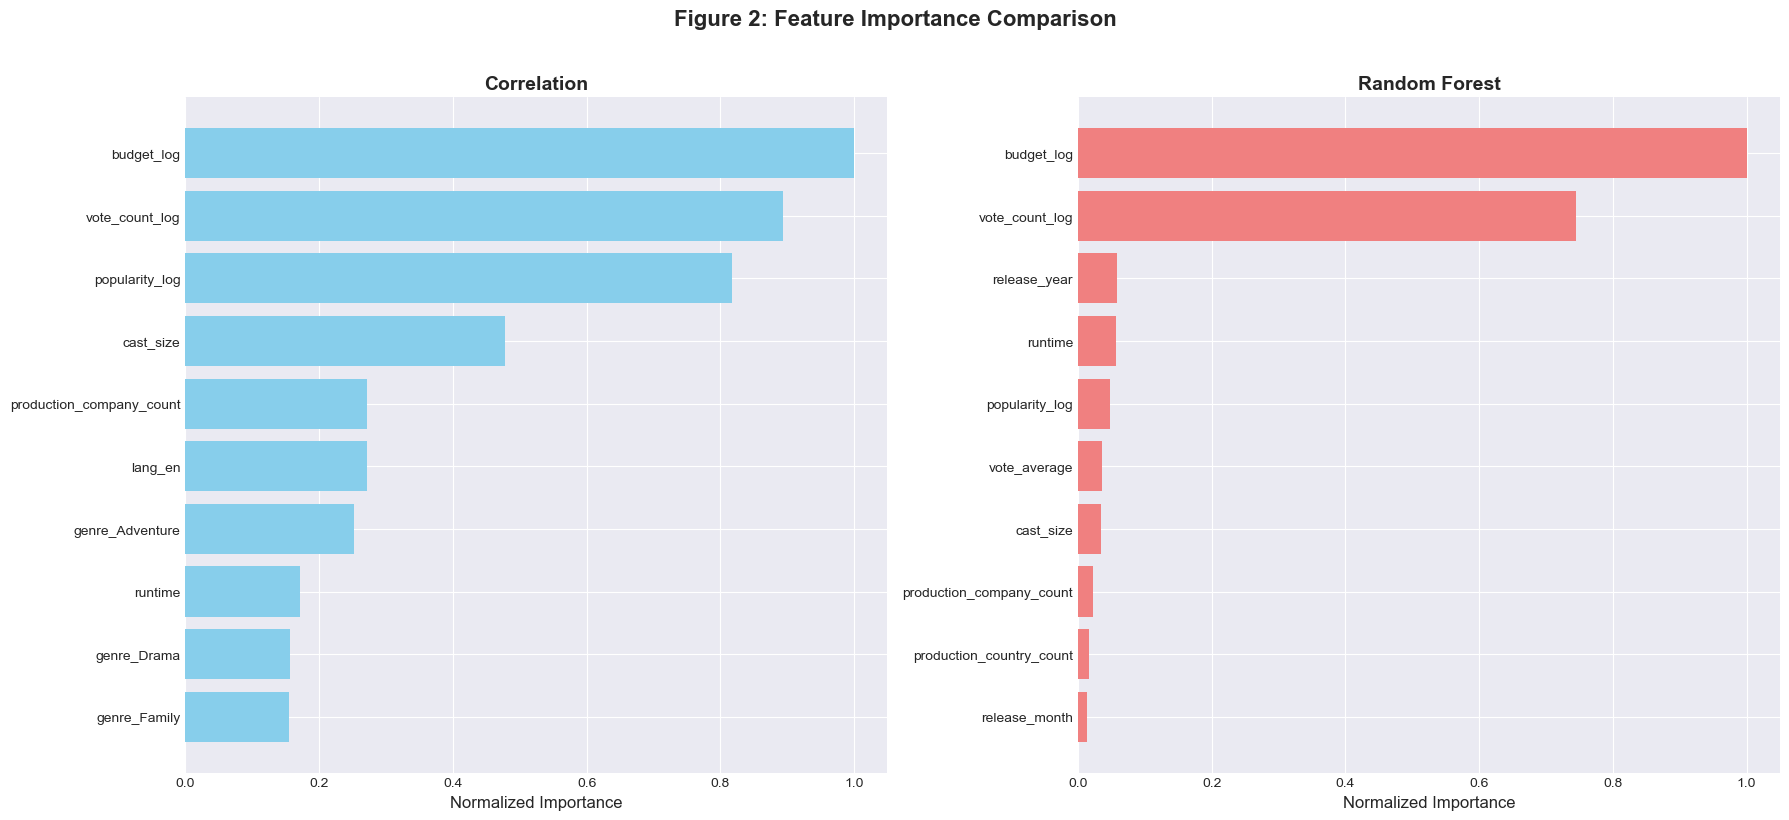


=== RANKING COMPARISON ===
                     feature  rank_corr  rank_rf  rank_diff
0                 budget_log          1        1          0
1             vote_count_log          2        2          0
22              release_year         23        3         20
7                    runtime          8        4          4
2             popularity_log          3        5          2
10              vote_average         11        6          5
3                  cast_size          4        7          3
4   production_company_count          5        8          3
12  production_country_count         13        9          4
20             release_month         21       10         11


In [19]:
# Beide Methoden kombinieren für Visualisierung
all_importance = pd.concat([method1_importance, method2_importance])

# Normalisierung für besseren Vergleich (0-1 Skala)
for method in ['Correlation', 'Random Forest']:
    mask = all_importance['method'] == method
    values = all_importance.loc[mask, 'importance']
    all_importance.loc[mask, 'importance_norm'] = (values - values.min()) / (values.max() - values.min())

# FIGURE 2: Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top-10 pro Methode (normalized)
for idx, method in enumerate(['Correlation', 'Random Forest']):
    data = all_importance[all_importance['method'] == method].head(10)
    axes[idx].barh(data['feature'], data['importance_norm'], color='skyblue' if idx == 0 else 'lightcoral')
    axes[idx].set_xlabel('Normalized Importance', fontsize=12)
    axes[idx].set_title(f'{method}', fontsize=14, fontweight='bold')
    axes[idx].invert_yaxis()

plt.suptitle('Figure 2: Feature Importance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figure2_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Ranking-Vergleich
print("\n=== RANKING COMPARISON ===")
ranking_comparison = pd.merge(
    method1_importance[['feature', 'rank']].rename(columns={'rank': 'rank_corr'}),
    method2_importance[['feature', 'rank']].rename(columns={'rank': 'rank_rf'}),
    on='feature'
)
ranking_comparison['rank_diff'] = abs(ranking_comparison['rank_corr'] - ranking_comparison['rank_rf'])
ranking_comparison = ranking_comparison.sort_values('rank_rf')
print(ranking_comparison.head(10))

## 🔬 ZELLE 11: Ablation Study - Individual Feature Ablation

**Experiment 1**: Jedes Feature einzeln ENTFERNEN und Performance-Drop messen

In [20]:
print("="*70)
print("ABLATION STUDY - INDIVIDUAL FEATURE REMOVAL")
print("="*70)
print("Evaluiere auf VALIDATION & TEST-Set")
print(f"Verwendete Hyperparameter: {BEST_PARAMS}")
print("="*70)
print(f"Baseline R² (Val): {baseline_r2:.4f}")
print(f"Baseline R² (Test): {baseline_results['r2_test']:.4f}")
print(f"\nEntferne jedes Feature einzeln und messe Performance-Drop...\n")

ablation_results = []

for i, feature in enumerate(X.columns, 1):
    # Alle Features außer diesem
    features_without = [f for f in X.columns if f != feature]
    
    X_train_ablation = X_train_scaled[features_without]
    X_val_ablation = X_val_scaled[features_without]
    X_test_ablation = X_test_scaled[features_without]
    
    # Modell trainieren (optimierte Hyperparameter!)
    model_ablation = RandomForestRegressor(
        n_estimators=BEST_PARAMS['n_estimators'],
        max_depth=BEST_PARAMS['max_depth'],
        min_samples_split=BEST_PARAMS['min_samples_split'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_ablation.fit(X_train_ablation, y_train)
    
    # Evaluieren auf Val & Test
    y_pred_val = model_ablation.predict(X_val_ablation)
    y_pred_test = model_ablation.predict(X_test_ablation)
    
    r2_val = r2_score(y_val, y_pred_val)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    # Performance-Drop berechnen
    r2_drop_val = baseline_r2 - r2_val
    r2_drop_test = baseline_results['r2_test'] - r2_test
    rmse_increase_val = rmse_val - baseline_rmse
    rmse_increase_test = rmse_test - baseline_results['rmse_test']
    
    ablation_results.append({
        'feature_removed': feature,
        'r2_val': r2_val,
        'r2_test': r2_test,
        'r2_drop_val': r2_drop_val,
        'r2_drop_test': r2_drop_test,
        'rmse_val': rmse_val,
        'rmse_test': rmse_test,
        'rmse_increase_val': rmse_increase_val,
        'rmse_increase_test': rmse_increase_test
    })
    
    print(f"[{i}/{len(X.columns)}] Without '{feature}': Val R²={r2_val:.4f} (Δ={r2_drop_val:.4f}), Test R²={r2_test:.4f} (Δ={r2_drop_test:.4f})")

# DataFrame erstellen und sortieren (nach Test R² Drop)
ablation_df = pd.DataFrame(ablation_results).sort_values('r2_drop_test', ascending=False)

print("\n" + "="*70)
print("MOST CRITICAL FEATURES (highest TEST performance drop when removed)")
print("="*70)
print(ablation_df[['feature_removed', 'r2_test', 'r2_drop_test', 'rmse_test', 'rmse_increase_test']].head(10).to_string(index=False))

print("\n" + "="*70)
print("LEAST IMPORTANT FEATURES (lowest TEST performance drop)")
print("="*70)
print(ablation_df[['feature_removed', 'r2_test', 'r2_drop_test', 'rmse_test', 'rmse_increase_test']].tail(10).to_string(index=False))

print("\n" + "="*70)
print("VALIDATION vs. TEST Comparison (Top-10)")
print("="*70)
print(ablation_df[['feature_removed', 'r2_drop_val', 'r2_drop_test']].head(10).to_string(index=False))

ABLATION STUDY - INDIVIDUAL FEATURE REMOVAL
Evaluiere auf VALIDATION & TEST-Set
Verwendete Hyperparameter: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 200}
Baseline R² (Val): 0.7373
Baseline R² (Test): 0.7292

Entferne jedes Feature einzeln und messe Performance-Drop...

[1/26] Without 'runtime': Val R²=0.7306 (Δ=0.0067), Test R²=0.7246 (Δ=0.0045)
[2/26] Without 'vote_average': Val R²=0.7397 (Δ=-0.0024), Test R²=0.7302 (Δ=-0.0011)
[3/26] Without 'director_count': Val R²=0.7372 (Δ=0.0001), Test R²=0.7303 (Δ=-0.0011)
[4/26] Without 'production_company_count': Val R²=0.7377 (Δ=-0.0004), Test R²=0.7309 (Δ=-0.0017)
[5/26] Without 'production_country_count': Val R²=0.7344 (Δ=0.0029), Test R²=0.7279 (Δ=0.0013)
[6/26] Without 'release_year': Val R²=0.7196 (Δ=0.0177), Test R²=0.7186 (Δ=0.0106)
[7/26] Without 'release_month': Val R²=0.7369 (Δ=0.0005), Test R²=0.7296 (Δ=-0.0005)
[8/26] Without 'cast_size': Val R²=0.7390 (Δ=-0.0017), Te

## 📊 ZELLE 12: FIGURE 3 - Individual Feature Ablation Visualization

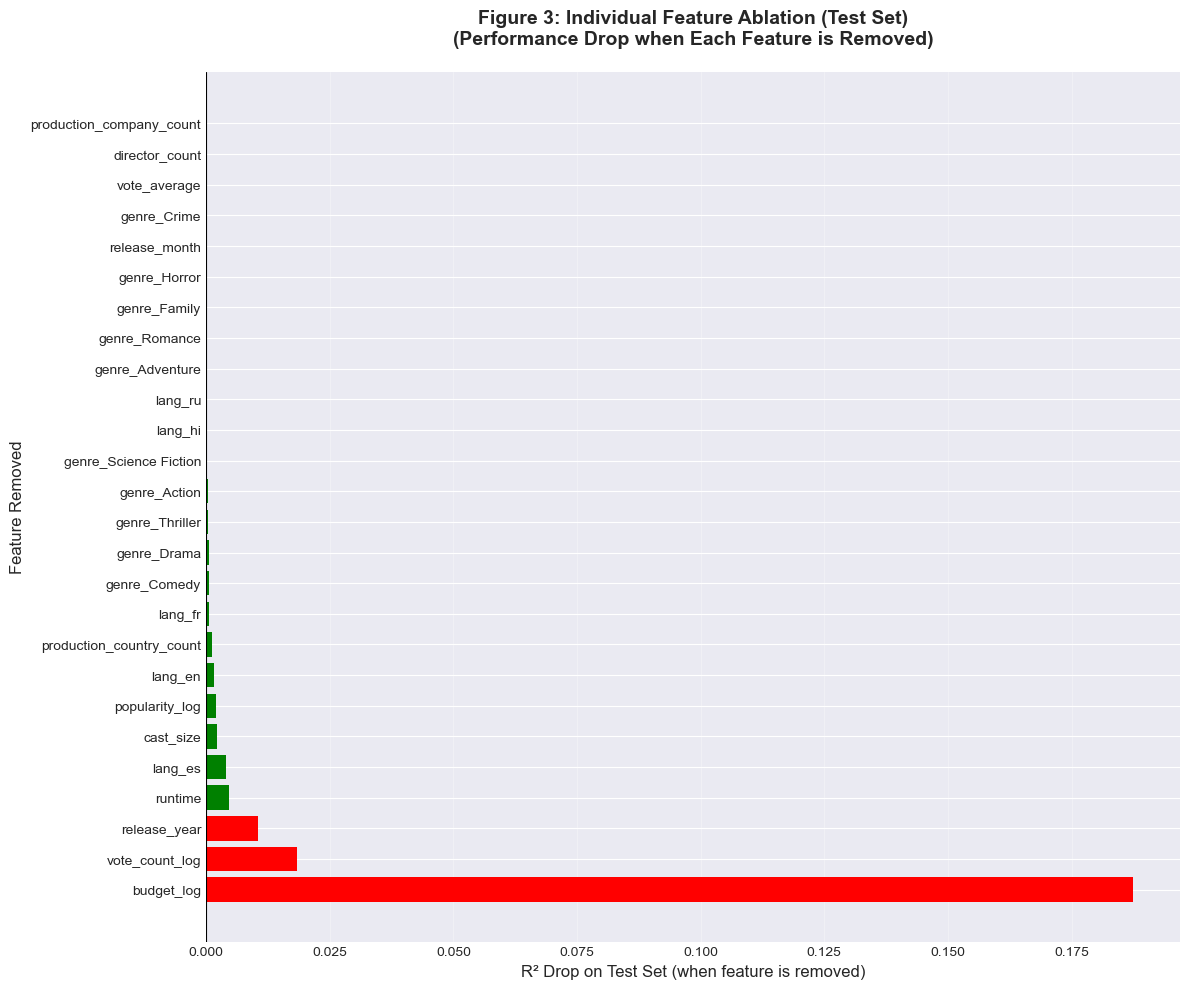

✓ Figure 3 saved: outputs/figures/figure3_individual_ablation.png


In [21]:
# FIGURE 3: Individual Feature Ablation (TEST-SET)
plt.figure(figsize=(12, 10))
colors = ['red' if x > 0.01 else 'orange' if x > 0.005 else 'green' for x in ablation_df['r2_drop_test']]
plt.barh(ablation_df['feature_removed'], ablation_df['r2_drop_test'], color=colors)
plt.xlabel('R² Drop on Test Set (when feature is removed)', fontsize=12)
plt.ylabel('Feature Removed', fontsize=12)
plt.title('Figure 3: Individual Feature Ablation (Test Set)\n(Performance Drop when Each Feature is Removed)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlim(0, None)  # y-Achse startet bei 0 (wissenschaftlich korrekt)
plt.axvline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/figure3_individual_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: outputs/figures/figure3_individual_ablation.png")

## 🔬 ZELLE: Feature Group Ablation

**Systematische Analyse von Feature-Gruppen:**
- Entferne ganze Feature-Gruppen (z.B. alle Genres)
- Messe Performance-Drop
- Verstehe Gruppen-Beiträge zum Modell

In [22]:
# ============================================================================
# FEATURE GROUP ABLATION
# ============================================================================

print("=" * 70)
print("FEATURE GROUP ABLATION STUDY")
print("=" * 70)
print(f"Verwendete Hyperparameter: {BEST_PARAMS}")

# Definiere Feature-Gruppen basierend auf semantischer Bedeutung
feature_groups = {
    'Financial': ['budget_log'],
    'Popularity': ['vote_count_log', 'popularity_log', 'vote_average'],
    'Genres': [col for col in X_train.columns if col.startswith('genre_')],
    'Languages': [col for col in X_train.columns if col.startswith('lang_')],
    'Production': ['production_company_count', 'production_country_count'],
    'Temporal': ['release_year', 'release_month'],
    'Content': ['runtime', 'cast_size', 'director_count']
}

# Zeige Gruppen-Übersicht
print("\nFeature-Gruppen:")
for group_name, features in feature_groups.items():
    print(f"  {group_name}: {len(features)} Features")
    print(f"    → {features[:3]}{'...' if len(features) > 3 else ''}")

# Baseline Performance (alle Features)
baseline_r2_val_group = baseline_results['r2_val']
baseline_r2_test_group = baseline_results['r2_test']
print(f"\nBaseline R² (Val): {baseline_r2_val_group:.4f}")
print(f"Baseline R² (Test): {baseline_r2_test_group:.4f}")

# Group Ablation: Entferne jede Gruppe und messe Performance
print("\n" + "=" * 70)
print("Führe Group Ablation durch...")
print("=" * 70)

group_ablation_results = []

for group_name, group_features in feature_groups.items():
    # Überprüfe welche Features tatsächlich vorhanden sind
    features_in_group = [f for f in group_features if f in X_train.columns]
    
    if not features_in_group:
        print(f"\n⚠️  {group_name}: Keine Features gefunden")
        continue
    
    print(f"\n{group_name} ({len(features_in_group)} Features):")
    print(f"  Entferne: {features_in_group}")
    
    # Erstelle Feature-Set ohne diese Gruppe
    X_train_without = X_train.drop(columns=features_in_group)
    X_val_without = X_val.drop(columns=features_in_group)
    X_test_without = X_test.drop(columns=features_in_group)
    
    # Scaler auf reduziertem Feature-Set
    scaler_temp = StandardScaler()
    X_train_without_scaled = scaler_temp.fit_transform(X_train_without)
    X_val_without_scaled = scaler_temp.transform(X_val_without)
    X_test_without_scaled = scaler_temp.transform(X_test_without)
    
    # Trainiere Modell ohne diese Gruppe (optimierte Hyperparameter!)
    model_without = RandomForestRegressor(
        n_estimators=BEST_PARAMS['n_estimators'],
        max_depth=BEST_PARAMS['max_depth'],
        min_samples_split=BEST_PARAMS['min_samples_split'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    model_without.fit(X_train_without_scaled, y_train)
    y_val_pred = model_without.predict(X_val_without_scaled)
    y_test_pred = model_without.predict(X_test_without_scaled)
    
    # Metriken berechnen
    r2_val_without = r2_score(y_val, y_val_pred)
    r2_test_without = r2_score(y_test, y_test_pred)
    rmse_val_without = np.sqrt(mean_squared_error(y_val, y_val_pred))
    rmse_test_without = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Performance-Drop berechnen
    r2_drop_val = baseline_r2_val_group - r2_val_without
    r2_drop_test = baseline_r2_test_group - r2_test_without
    rmse_increase_val = rmse_val_without - baseline_results['rmse_val']
    rmse_increase_test = rmse_test_without - baseline_results['rmse_test']
    
    print(f"  R² ohne Gruppe (Val):  {r2_val_without:.4f} (Drop: {r2_drop_val:.4f}, {r2_drop_val/baseline_r2_val_group*100:.1f}%)")
    print(f"  R² ohne Gruppe (Test): {r2_test_without:.4f} (Drop: {r2_drop_test:.4f}, {r2_drop_test/baseline_r2_test_group*100:.1f}%)")
    
    # Speichere Ergebnisse
    group_ablation_results.append({
        'group': group_name,
        'num_features': len(features_in_group),
        'features': ', '.join(features_in_group[:5]) + ('...' if len(features_in_group) > 5 else ''),
        'r2_val_without': r2_val_without,
        'r2_test_without': r2_test_without,
        'r2_drop_val': r2_drop_val,
        'r2_drop_test': r2_drop_test,
        'r2_drop_pct_val': r2_drop_val / baseline_r2_val_group * 100,
        'r2_drop_pct_test': r2_drop_test / baseline_r2_test_group * 100,
        'rmse_val_without': rmse_val_without,
        'rmse_test_without': rmse_test_without,
        'rmse_increase_val': rmse_increase_val,
        'rmse_increase_test': rmse_increase_test
    })

# Erstelle DataFrame
group_ablation_df = pd.DataFrame(group_ablation_results)
group_ablation_df = group_ablation_df.sort_values('r2_drop_test', ascending=False)

print("\n" + "=" * 70)
print("ZUSAMMENFASSUNG - Feature Group Ablation (TEST-SET)")
print("=" * 70)
print(group_ablation_df[['group', 'num_features', 'r2_drop_test', 'r2_drop_pct_test']].to_string(index=False))

print("\n" + "=" * 70)
print("VALIDATION vs. TEST Comparison")
print("=" * 70)
print(group_ablation_df[['group', 'r2_drop_val', 'r2_drop_test']].to_string(index=False))

print("\n" + "=" * 70)
print("INTERPRETATION (basierend auf TEST-SET)")
print("=" * 70)
most_important = group_ablation_df.iloc[0]
least_important = group_ablation_df.iloc[-1]

print(f"\nWichtigste Gruppe: {most_important['group']}")
print(f"  → R² Drop (Test): {most_important['r2_drop_test']:.4f} ({most_important['r2_drop_pct_test']:.1f}%)")
print(f"  → Enthält: {most_important['features']}")

print(f"\nUnwichtigste Gruppe: {least_important['group']}")
print(f"  → R² Drop (Test): {least_important['r2_drop_test']:.4f} ({least_important['r2_drop_pct_test']:.1f}%)")
print(f"  → Enthält: {least_important['features']}")

FEATURE GROUP ABLATION STUDY
Verwendete Hyperparameter: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 200}

Feature-Gruppen:
  Financial: 1 Features
    → ['budget_log']
  Popularity: 3 Features
    → ['vote_count_log', 'popularity_log', 'vote_average']
  Genres: 10 Features
    → ['genre_Drama', 'genre_Comedy', 'genre_Action']...
  Languages: 5 Features
    → ['lang_en', 'lang_hi', 'lang_fr']...
  Production: 2 Features
    → ['production_company_count', 'production_country_count']
  Temporal: 2 Features
    → ['release_year', 'release_month']
  Content: 3 Features
    → ['runtime', 'cast_size', 'director_count']

Baseline R² (Val): 0.7373
Baseline R² (Test): 0.7292

Führe Group Ablation durch...

Financial (1 Features):
  Entferne: ['budget_log']
  R² ohne Gruppe (Val):  0.5727 (Drop: 0.1646, 22.3%)
  R² ohne Gruppe (Test): 0.5417 (Drop: 0.1875, 25.7%)

Popularity (3 Features):
  Entferne: ['vote_count_log', 'popularity_log'

## 📊 FIGURE 6: Feature Group Ablation Visualization

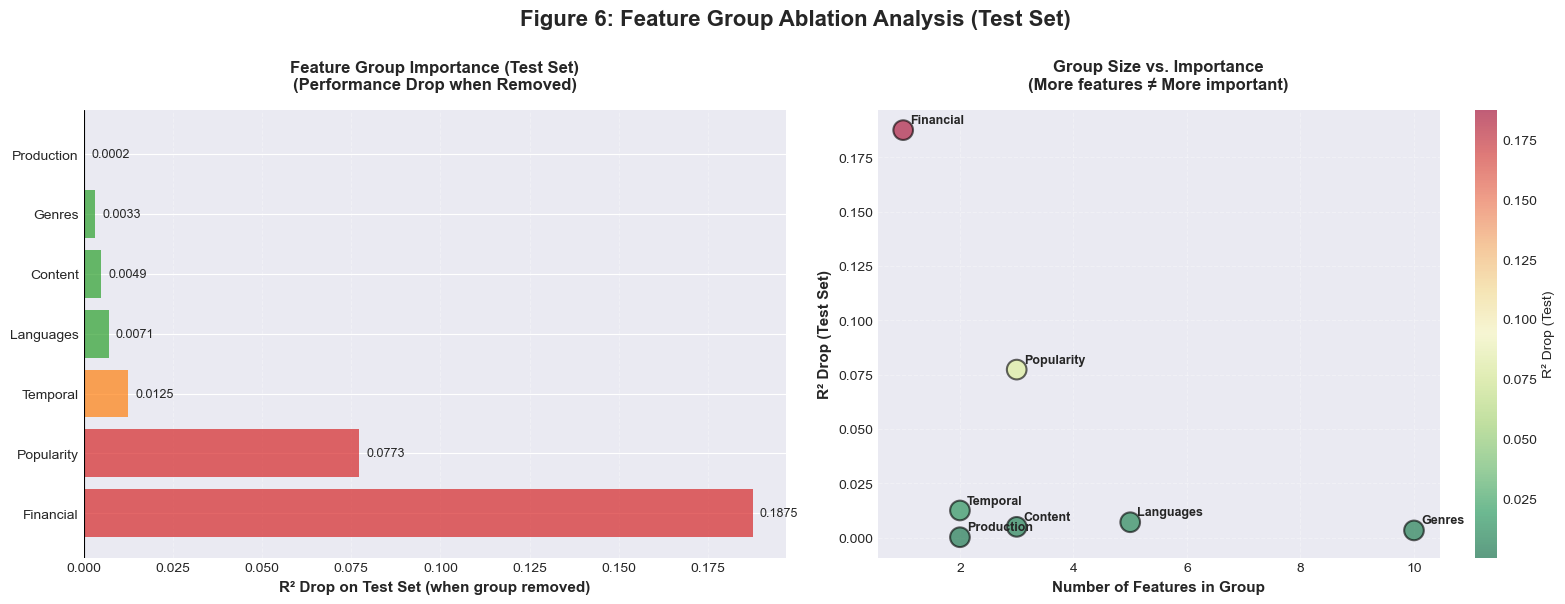


✓ Figure 6 saved: outputs/figures/figure6_group_ablation.png


In [23]:
# ============================================================================
# FIGURE 6: Feature Group Contributions (TEST-SET)
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² Drop pro Gruppe (TEST-SET)
ax1 = axes[0]
colors = ['#d62728' if x > 0.05 else '#ff7f0e' if x > 0.01 else '#2ca02c' 
          for x in group_ablation_df['r2_drop_test']]
          
bars = ax1.barh(group_ablation_df['group'], group_ablation_df['r2_drop_test'], color=colors, alpha=0.7)
ax1.set_xlabel('R² Drop on Test Set (when group removed)', fontsize=11, fontweight='bold')
ax1.set_title('Feature Group Importance (Test Set)\n(Performance Drop when Removed)', 
              fontsize=12, fontweight='bold', pad=15)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Annotations
for i, (bar, val) in enumerate(zip(bars, group_ablation_df['r2_drop_test'])):
    width = bar.get_width()
    ax1.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{val:.4f}', ha='left', va='center', fontsize=9)

# Plot 2: Anzahl Features vs. Wichtigkeit
ax2 = axes[1]
scatter = ax2.scatter(group_ablation_df['num_features'], 
                      group_ablation_df['r2_drop_test'],
                      s=200, alpha=0.6, c=group_ablation_df['r2_drop_test'],
                      cmap='RdYlGn_r', edgecolors='black', linewidth=1.5)

# Labels für jeden Punkt
for idx, row in group_ablation_df.iterrows():
    ax2.annotate(row['group'], 
                (row['num_features'], row['r2_drop_test']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax2.set_xlabel('Number of Features in Group', fontsize=11, fontweight='bold')
ax2.set_ylabel('R² Drop (Test Set)', fontsize=11, fontweight='bold')
ax2.set_title('Group Size vs. Importance\n(More features ≠ More important)', 
              fontsize=12, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=ax2, label='R² Drop (Test)')

plt.suptitle('Figure 6: Feature Group Ablation Analysis (Test Set)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('outputs/figures/figure6_group_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure 6 saved: outputs/figures/figure6_group_ablation.png")

In [24]:
# ============================================================================
# EXPORT: Group Ablation Results
# ============================================================================

# Speichere Tabelle
group_ablation_df.to_csv('outputs/results/table6_group_ablation.csv', index=False)
print("✓ Table 6 saved: outputs/results/table6_group_ablation.csv")

print("\n" + "=" * 70)
print("ALLE ERGEBNISSE EXPORTIERT")
print("=" * 70)
print("Tabellen:")
print("  - table1_dataset_characteristics.csv")
print("  - table2_baseline_performance.csv")
print("  - table3_feature_importance_rankings.csv")
print("  - table4_individual_ablation.csv")
print("  - table5_topk_selection.csv")
print("  - table6_group_ablation.csv  ← NEU")
print("\nFiguren:")
print("  - figure1_correlation_matrix.png")
print("  - figure2_feature_importance_comparison.png")
print("  - figure3_individual_ablation.png")
print("  - figure4_cumulative_addition.png")
print("  - figure5_topk_performance.png")
print("  - figure6_group_ablation.png  ← NEU")


✓ Table 6 saved: outputs/results/table6_group_ablation.csv

ALLE ERGEBNISSE EXPORTIERT
Tabellen:
  - table1_dataset_characteristics.csv
  - table2_baseline_performance.csv
  - table3_feature_importance_rankings.csv
  - table4_individual_ablation.csv
  - table5_topk_selection.csv
  - table6_group_ablation.csv  ← NEU

Figuren:
  - figure1_correlation_matrix.png
  - figure2_feature_importance_comparison.png
  - figure3_individual_ablation.png
  - figure4_cumulative_addition.png
  - figure5_topk_performance.png
  - figure6_group_ablation.png  ← NEU


## 🔬 ZELLE 13: Ablation Study - Cumulative Feature Addition

**Experiment 2**: Features schrittweise HINZUFÜGEN (nach Wichtigkeit sortiert)

In [25]:
# Features nach RF-Wichtigkeit sortieren
features_sorted = feature_importance_rf.index.tolist()

print("="*70)
print("ABLATION STUDY - CUMULATIVE FEATURE ADDITION")
print("="*70)
print(f"Verwendete Hyperparameter: {BEST_PARAMS}")
print(f"Features sortiert nach Wichtigkeit (RF): {features_sorted}")
print(f"\nFüge Features schrittweise hinzu...\n")

cumulative_results = []

for i in range(1, len(features_sorted) + 1):
    # Top-i Features
    top_features = features_sorted[:i]
    
    X_train_cum = X_train_scaled[top_features]
    X_val_cum = X_val_scaled[top_features]
    X_test_cum = X_test_scaled[top_features]
    
    # Training (optimierte Hyperparameter!)
    model_cum = RandomForestRegressor(
        n_estimators=BEST_PARAMS['n_estimators'],
        max_depth=BEST_PARAMS['max_depth'],
        min_samples_split=BEST_PARAMS['min_samples_split'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_cum.fit(X_train_cum, y_train)
    
    # Evaluation auf Val & Test
    y_pred_val = model_cum.predict(X_val_cum)
    y_pred_test = model_cum.predict(X_test_cum)
    
    r2_val = r2_score(y_val, y_pred_val)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    # % von Baseline
    pct_of_baseline_val = (r2_val / baseline_r2) * 100
    pct_of_baseline_test = (r2_test / baseline_results['r2_test']) * 100
    
    cumulative_results.append({
        'num_features': i,
        'last_feature_added': top_features[-1],
        'r2_val': r2_val,
        'r2_test': r2_test,
        'rmse_val': rmse_val,
        'rmse_test': rmse_test,
        'pct_of_baseline_val': pct_of_baseline_val,
        'pct_of_baseline_test': pct_of_baseline_test
    })
    
    if i <= 10 or i % 5 == 0 or i == len(features_sorted):
        print(f"[{i:2d} Features] Val R²={r2_val:.4f} ({pct_of_baseline_val:5.1f}%), Test R²={r2_test:.4f} ({pct_of_baseline_test:5.1f}%) | Added: {top_features[-1]}")

cumulative_df = pd.DataFrame(cumulative_results)

print("\n" + "="*70)
print("SUMMARY (TEST-SET PERFORMANCE)")
print("="*70)
print(f"Baseline (All {len(X.columns)} features): Test R²={baseline_results['r2_test']:.4f}")

# Wann erreichen wir 90%, 95% der Baseline (basierend auf Test)?
for threshold in [90, 95, 98]:
    rows = cumulative_df[cumulative_df['pct_of_baseline_test'] >= threshold]
    if len(rows) > 0:
        first_row = rows.iloc[0]
        print(f"\n{threshold}% of Baseline (Test) erreicht mit {first_row['num_features']} Features")
        print(f"  Test R²={first_row['r2_test']:.4f}, Val R²={first_row['r2_val']:.4f}")
        print(f"  Features: {features_sorted[:first_row['num_features']]}")

print("\n" + "="*70)
print("VALIDATION vs. TEST Comparison (Selected Milestones)")
print("="*70)
milestone_indices = [0, 2, 4, 6, 9, len(cumulative_df)-1]  # 1, 3, 5, 7, 10, all features
print(cumulative_df.iloc[milestone_indices][['num_features', 'r2_val', 'r2_test', 'pct_of_baseline_test']].to_string(index=False))

ABLATION STUDY - CUMULATIVE FEATURE ADDITION
Verwendete Hyperparameter: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 200}
Features sortiert nach Wichtigkeit (RF): ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average', 'cast_size', 'production_company_count', 'production_country_count', 'release_month', 'lang_en', 'genre_Drama', 'lang_fr', 'director_count', 'genre_Thriller', 'genre_Comedy', 'genre_Horror', 'genre_Action', 'genre_Crime', 'lang_es', 'genre_Adventure', 'genre_Family', 'genre_Science Fiction', 'genre_Romance', 'lang_ru', 'lang_hi']

Füge Features schrittweise hinzu...

[ 1 Features] Val R²=0.5943 ( 80.6%), Test R²=0.5965 ( 81.8%) | Added: budget_log
[ 2 Features] Val R²=0.6773 ( 91.9%), Test R²=0.6717 ( 92.1%) | Added: vote_count_log
[ 3 Features] Val R²=0.6990 ( 94.8%), Test R²=0.6924 ( 95.0%) | Added: release_year
[ 4 Features] Val R²=0.7124 ( 96.6%), Test R²=0.7127 ( 97.7%

## 📊 ZELLE 14: FIGURE 4 - Cumulative Feature Addition Curve

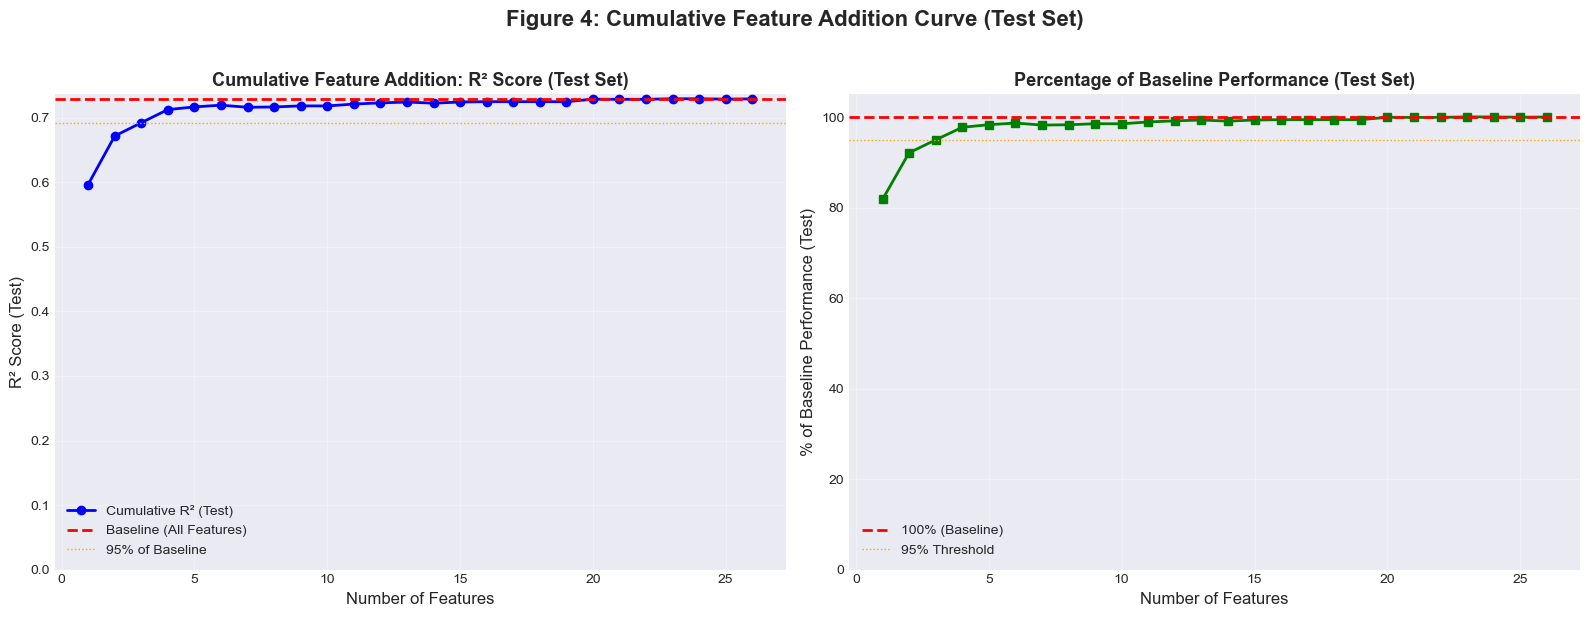

✓ Figure 4 saved: outputs/figures/figure4_cumulative_addition.png


In [26]:
# FIGURE 4: Cumulative Feature Addition (TEST-SET)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² Score (TEST-SET)
axes[0].plot(cumulative_df['num_features'], cumulative_df['r2_test'], 
             marker='o', linewidth=2, markersize=6, color='blue', label='Cumulative R² (Test)')
axes[0].axhline(baseline_results['r2_test'], color='red', linestyle='--', linewidth=2, label='Baseline (All Features)')
axes[0].axhline(baseline_results['r2_test'] * 0.95, color='orange', linestyle=':', linewidth=1, label='95% of Baseline')
axes[0].set_xlabel('Number of Features', fontsize=12)
axes[0].set_ylabel('R² Score (Test)', fontsize=12)
axes[0].set_title('Cumulative Feature Addition: R² Score (Test Set)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, None)  # y-Achse startet bei 0
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: % of Baseline (TEST-SET)
axes[1].plot(cumulative_df['num_features'], cumulative_df['pct_of_baseline_test'], 
             marker='s', linewidth=2, markersize=6, color='green')
axes[1].axhline(100, color='red', linestyle='--', linewidth=2, label='100% (Baseline)')
axes[1].axhline(95, color='orange', linestyle=':', linewidth=1, label='95% Threshold')
axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('% of Baseline Performance (Test)', fontsize=12)
axes[1].set_title('Percentage of Baseline Performance (Test Set)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])  # y-Achse bei 0

plt.suptitle('Figure 4: Cumulative Feature Addition Curve (Test Set)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figure4_cumulative_addition.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: outputs/figures/figure4_cumulative_addition.png")

## 🔬 ZELLE 15: Ablation Study - Top-K Feature Selection

**Experiment 3**: Modelle mit Top-3, 5, 7, 10 Features vergleichen

In [27]:
# K-Werte testen
k_values = [3, 5, 7, 10, len(features_sorted)]

print("="*70)
print("ABLATION STUDY - TOP-K FEATURE SELECTION")
print("="*70)
print(f"Verwendete Hyperparameter: {BEST_PARAMS}")
print(f"Testing K values: {k_values}\n")

topk_results = []

for k in k_values:
    top_k_features = features_sorted[:k]
    
    X_train_k = X_train_scaled[top_k_features]
    X_val_k = X_val_scaled[top_k_features]
    X_test_k = X_test_scaled[top_k_features]
    
    # Modell trainieren (optimierte Hyperparameter!)
    model_k = RandomForestRegressor(
        n_estimators=BEST_PARAMS['n_estimators'],
        max_depth=BEST_PARAMS['max_depth'],
        min_samples_split=BEST_PARAMS['min_samples_split'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_k.fit(X_train_k, y_train)
    
    # Evaluation auf Train, Val, Test
    y_pred_train_k = model_k.predict(X_train_k)
    y_pred_val_k = model_k.predict(X_val_k)
    y_pred_test_k = model_k.predict(X_test_k)
    
    r2_train = r2_score(y_train, y_pred_train_k)
    r2_val = r2_score(y_val, y_pred_val_k)
    r2_test = r2_score(y_test, y_pred_test_k)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val_k))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test_k))
    mae_val = mean_absolute_error(y_val, y_pred_val_k)
    mae_test = mean_absolute_error(y_test, y_pred_test_k)
    
    # % of Baseline
    pct_of_baseline_val = (r2_val / baseline_r2) * 100
    pct_of_baseline_test = (r2_test / baseline_results['r2_test']) * 100
    
    topk_results.append({
        'k': k,
        'features': top_k_features,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'r2_test': r2_test,
        'rmse_val': rmse_val,
        'rmse_test': rmse_test,
        'mae_val': mae_val,
        'mae_test': mae_test,
        'pct_of_baseline_val': pct_of_baseline_val,
        'pct_of_baseline_test': pct_of_baseline_test
    })
    
    print(f"\nTop-{k} Features:")
    print(f"  Features: {top_k_features}")
    print(f"  R² (Train): {r2_train:.4f}")
    print(f"  R² (Val):   {r2_val:.4f} ({pct_of_baseline_val:.1f}% of baseline)")
    print(f"  R² (Test):  {r2_test:.4f} ({pct_of_baseline_test:.1f}% of baseline)")
    print(f"  RMSE (Val): {rmse_val:.4f} (log-scale)")
    print(f"  RMSE (Test): {rmse_test:.4f} (log-scale)")
    print(f"  MAE (Val):  {mae_val:.4f} (log-scale)")
    print(f"  MAE (Test):  {mae_test:.4f} (log-scale)")

topk_df = pd.DataFrame(topk_results)

print("\n" + "="*70)
print("TOP-K COMPARISON TABLE (TEST-SET PERFORMANCE)")
print("="*70)
print(topk_df[['k', 'r2_test', 'rmse_test', 'pct_of_baseline_test']].to_string(index=False))

print("\n" + "="*70)
print("VALIDATION vs. TEST R² Comparison")
print("="*70)
print(topk_df[['k', 'r2_val', 'r2_test']].to_string(index=False))

ABLATION STUDY - TOP-K FEATURE SELECTION
Verwendete Hyperparameter: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 200}
Testing K values: [3, 5, 7, 10, 26]


Top-3 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year']
  R² (Train): 0.8240
  R² (Val):   0.6990 (94.8% of baseline)
  R² (Test):  0.6924 (95.0% of baseline)
  RMSE (Val): 1.5941 (log-scale)
  RMSE (Test): 1.6990 (log-scale)
  MAE (Val):  1.0273 (log-scale)
  MAE (Test):  1.1204 (log-scale)

Top-5 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']
  R² (Train): 0.8535
  R² (Val):   0.7114 (96.5% of baseline)
  R² (Test):  0.7169 (98.3% of baseline)
  RMSE (Val): 1.5610 (log-scale)
  RMSE (Test): 1.6301 (log-scale)
  MAE (Val):  0.9919 (log-scale)
  MAE (Test):  1.0658 (log-scale)

Top-7 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average', 'c

## 📊 ZELLE 16: FIGURE 5 - Performance vs. Number of Features

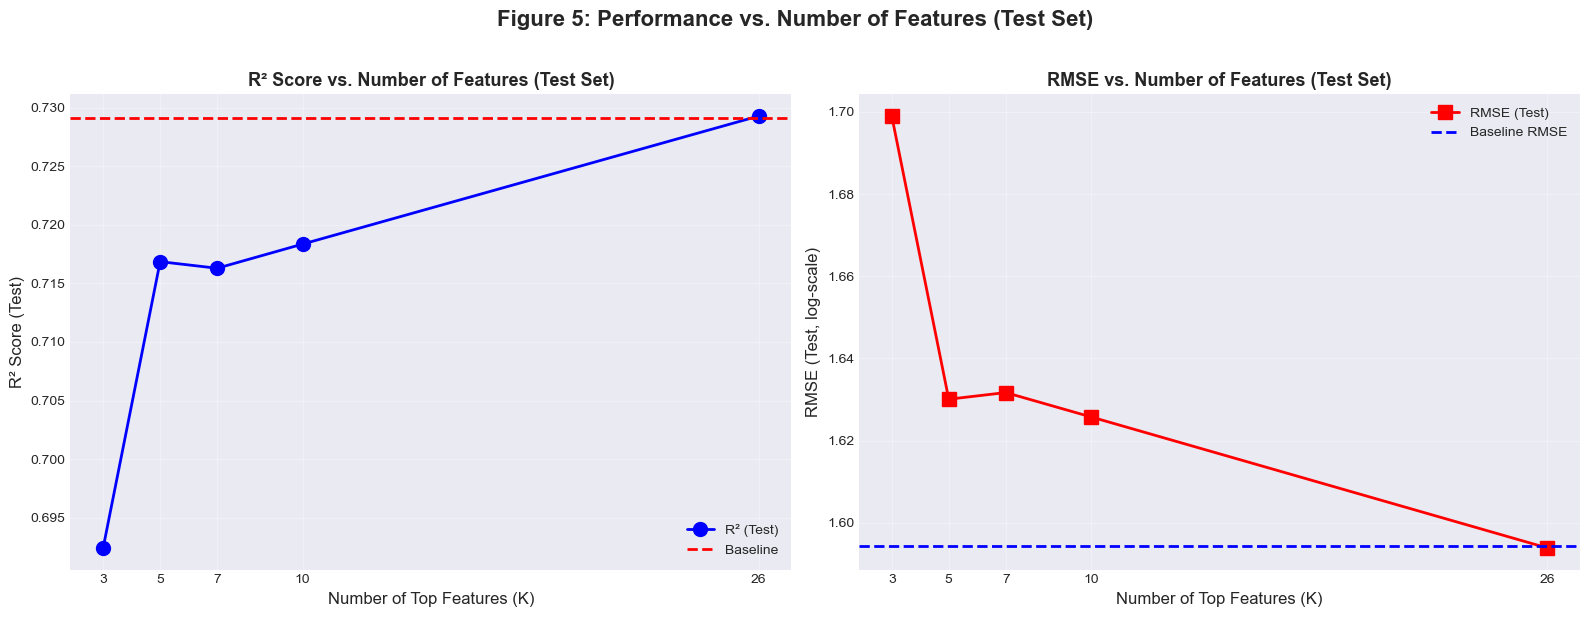

✓ Figure 5 saved: outputs/figures/figure5_topk_performance.png


In [28]:
# FIGURE 5: Performance vs Number of Features (TEST-SET)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² Score (TEST-SET)
axes[0].plot(topk_df['k'], topk_df['r2_test'], marker='o', linewidth=2, 
             markersize=10, color='blue', label='R² (Test)')
axes[0].axhline(baseline_results['r2_test'], color='red', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_xlabel('Number of Top Features (K)', fontsize=12)
axes[0].set_ylabel('R² Score (Test)', fontsize=12)
axes[0].set_title('R² Score vs. Number of Features (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(topk_df['k'])

# Plot 2: RMSE (TEST-SET)
axes[1].plot(topk_df['k'], topk_df['rmse_test'], marker='s', linewidth=2, 
             markersize=10, color='red', label='RMSE (Test)')
axes[1].axhline(baseline_results['rmse_test'], color='blue', linestyle='--', linewidth=2, label='Baseline RMSE')
axes[1].set_xlabel('Number of Top Features (K)', fontsize=12)
axes[1].set_ylabel('RMSE (Test, log-scale)', fontsize=12)
axes[1].set_title('RMSE vs. Number of Features (Test Set)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(topk_df['k'])

plt.suptitle('Figure 5: Performance vs. Number of Features (Test Set)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figure5_topk_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: outputs/figures/figure5_topk_performance.png")

## 📊 ZELLE 17: FIGURE 6 - Predicted vs Actual (Best Model)

Wähle das beste K basierend auf R² Score

Bestes Modell: Top-5 Features
Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']
R² (Test): 0.7169 (98.3% of baseline)
Hyperparameter: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 200}


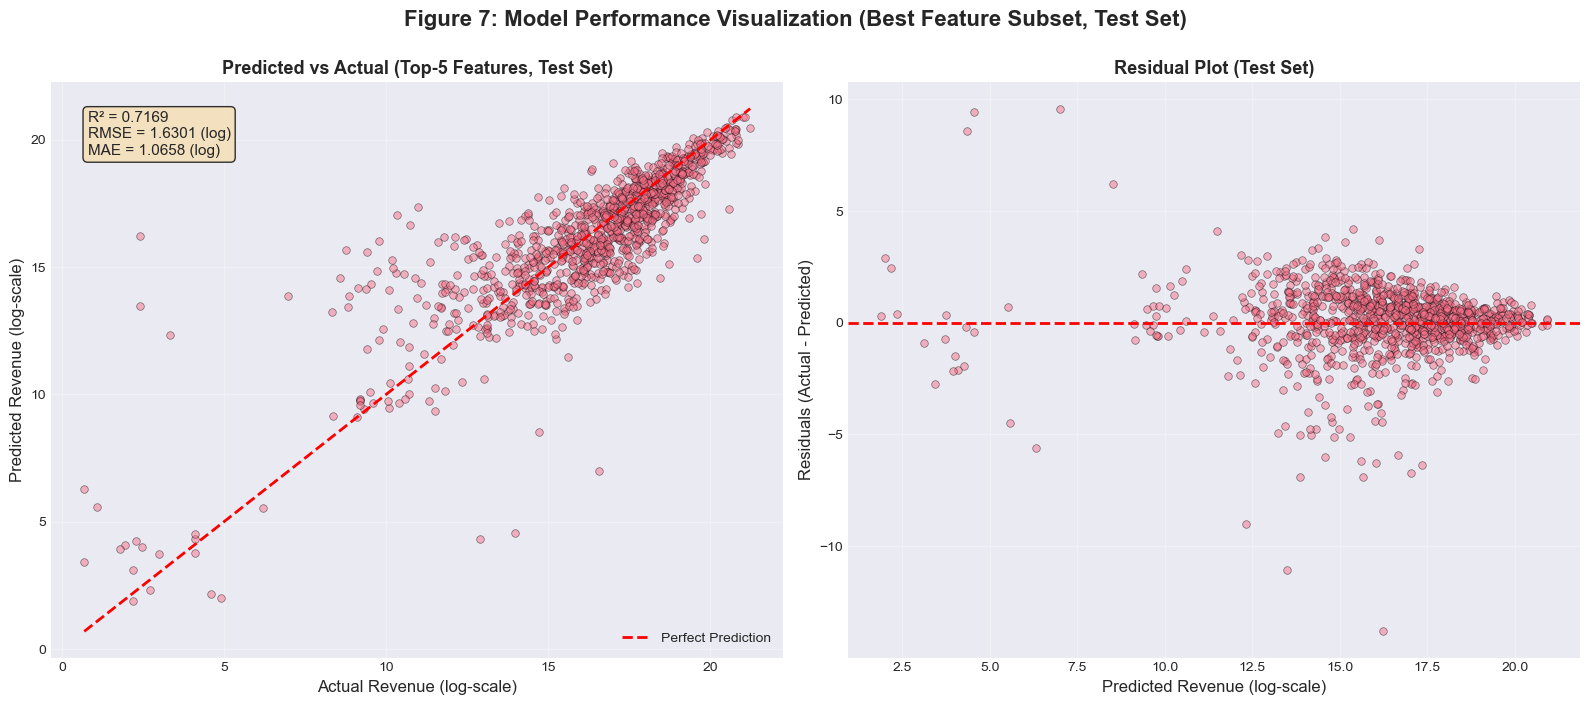


✓ Figure 7 saved: outputs/figures/figure7_predicted_vs_actual.png


In [29]:
# Bestes K wählen (höchster R² bei niedrigerem K)
# Kriterium: Mind. 95% der Baseline mit möglichst wenigen Features (basierend auf TEST-SET)
best_row = topk_df[topk_df['pct_of_baseline_test'] >= 95].iloc[0]
best_k = int(best_row['k'])
best_features = features_sorted[:best_k]

print(f"Bestes Modell: Top-{best_k} Features")
print(f"Features: {best_features}")
print(f"R² (Test): {best_row['r2_test']:.4f} ({best_row['pct_of_baseline_test']:.1f}% of baseline)")
print(f"Hyperparameter: {BEST_PARAMS}")

# Modell mit besten Features trainieren (optimierte Hyperparameter!)
X_train_best = X_train_scaled[best_features]
X_test_best = X_test_scaled[best_features]

model_best = RandomForestRegressor(
    n_estimators=BEST_PARAMS['n_estimators'],
    max_depth=BEST_PARAMS['max_depth'],
    min_samples_split=BEST_PARAMS['min_samples_split'],
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_best.fit(X_train_best, y_train)
y_pred_best = model_best.predict(X_test_best)

# FIGURE 7: Predicted vs Actual (TEST-SET)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Scatter Plot
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Revenue (log-scale)', fontsize=12)
axes[0].set_ylabel('Predicted Revenue (log-scale)', fontsize=12)
axes[0].set_title(f'Predicted vs Actual (Top-{best_k} Features, Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Text-Box mit Metriken
textstr = f"R² = {best_row['r2_test']:.4f}\nRMSE = {best_row['rmse_test']:.4f} (log)\nMAE = {best_row['mae_test']:.4f} (log)"
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)

# Plot 2: Residual Plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Revenue (log-scale)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot (Test Set)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 7: Model Performance Visualization (Best Feature Subset, Test Set)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('outputs/figures/figure7_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure 7 saved: outputs/figures/figure7_predicted_vs_actual.png")

## 6. STATISTISCHE VALIDIERUNG

Wir validieren unsere Ergebnisse statistisch:

1. **Konfidenzintervalle (95% CI):** Bootstrap-Resampling (n=1000) für alle Metriken
2. **Paired t-Tests:** Vergleiche zwischen Baseline und Top-K Modellen
3. **Signifikanz-Level:** α = 0.05

**Zweck:** Sicherstellen, dass Performance-Unterschiede nicht nur durch Zufall entstanden sind.

In [30]:
print("="*70)
print("BOOTSTRAP KONFIDENZINTERVALLE (95% CI) - TEST-SET")
print("="*70)
print(f"Verwendete Hyperparameter: {BEST_PARAMS}")
print("Berechne für alle Modelle mit n=1000 Bootstrap-Iterationen auf TEST-SET...\n")

from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Bootstrap-Funktion
def bootstrap_metric(y_true, y_pred, metric_func, n_iterations=1000, ci=95):
    """Berechne Bootstrap-CI für eine Metrik"""
    n_samples = len(y_true)
    scores = []
    
    for i in range(n_iterations):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
        y_pred_boot = y_pred[indices]
        
        score = metric_func(y_true_boot, y_pred_boot)
        scores.append(score)
    
    alpha = (100 - ci) / 2
    lower = np.percentile(scores, alpha)
    upper = np.percentile(scores, 100 - alpha)
    mean_score = np.mean(scores)
    
    return mean_score, lower, upper

# Predictions sammeln für alle Modelle auf TEST-SET
predictions_test = {}

# Baseline bereits vorhanden
predictions_test['Baseline (All Features)'] = model.predict(X_test_scaled)

# Top-K Modelle trainieren und predicten (optimierte Hyperparameter!)
print("Trainiere Top-K Modelle...")
for k in [3, 5, 7, 10]:
    top_features = topk_df[topk_df['k'] == k]['features'].values[0]
    
    # Konvertiere String zu Liste falls nötig
    if isinstance(top_features, str):
        top_features = [f.strip() for f in top_features.split(',')]
    
    X_train_k = X_train_scaled[top_features]
    X_test_k = X_test_scaled[top_features]
    
    model_k = RandomForestRegressor(
        n_estimators=BEST_PARAMS['n_estimators'],
        max_depth=BEST_PARAMS['max_depth'],
        min_samples_split=BEST_PARAMS['min_samples_split'],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_k.fit(X_train_k, y_train)
    predictions_test[f'Top-{k} Features'] = model_k.predict(X_test_k)
    print(f"  ✓ Top-{k} trainiert")

# Bootstrap CIs für alle Modelle auf TEST-SET
print("\nBerechne Bootstrap-Konfidenzintervalle (TEST-SET)...")
ci_results = []

for model_name, y_pred in predictions_test.items():
    print(f"\n{model_name}:")
    
    # R² CI
    r2_mean, r2_lower, r2_upper = bootstrap_metric(
        y_test, y_pred, r2_score, n_iterations=1000
    )
    
    # RMSE CI
    def rmse_metric(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))
    
    rmse_mean, rmse_lower, rmse_upper = bootstrap_metric(
        y_test, y_pred, rmse_metric, n_iterations=1000
    )
    
    # MAE CI
    mae_mean, mae_lower, mae_upper = bootstrap_metric(
        y_test, y_pred, mean_absolute_error, n_iterations=1000
    )
    
    ci_results.append({
        'model': model_name,
        'r2_mean': r2_mean,
        'r2_lower': r2_lower,
        'r2_upper': r2_upper,
        'r2_ci_width': r2_upper - r2_lower,
        'rmse_mean': rmse_mean,
        'rmse_lower': rmse_lower,
        'rmse_upper': rmse_upper,
        'mae_mean': mae_mean,
        'mae_lower': mae_lower,
        'mae_upper': mae_upper
    })
    
    print(f"  R²:   {r2_mean:.4f} [{r2_lower:.4f}, {r2_upper:.4f}]")
    print(f"  RMSE: {rmse_mean:.4f} [{rmse_lower:.4f}, {rmse_upper:.4f}] (log-scale)")
    print(f"  MAE:  {mae_mean:.4f} [{mae_lower:.4f}, {mae_upper:.4f}] (log-scale)")

ci_df = pd.DataFrame(ci_results)

print("\n" + "="*70)
print("✓ Bootstrap-Konfidenzintervalle berechnet (TEST-SET)")
print("="*70)

BOOTSTRAP KONFIDENZINTERVALLE (95% CI) - TEST-SET
Verwendete Hyperparameter: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 15, 'n_estimators': 200}
Berechne für alle Modelle mit n=1000 Bootstrap-Iterationen auf TEST-SET...

Trainiere Top-K Modelle...
  ✓ Top-3 trainiert
  ✓ Top-5 trainiert
  ✓ Top-7 trainiert
  ✓ Top-10 trainiert

Berechne Bootstrap-Konfidenzintervalle (TEST-SET)...

Baseline (All Features):
  R²:   0.7288 [0.6669, 0.7827]
  RMSE: 1.5889 [1.4226, 1.7753] (log-scale)
  MAE:  1.0245 [0.9547, 1.0984] (log-scale)

Top-3 Features:
  R²:   0.6922 [0.6276, 0.7511]
  RMSE: 1.6921 [1.5331, 1.8704] (log-scale)
  MAE:  1.1184 [1.0473, 1.1967] (log-scale)

Top-5 Features:
  R²:   0.7146 [0.6517, 0.7703]
  RMSE: 1.6311 [1.4520, 1.8098] (log-scale)
  MAE:  1.0667 [0.9947, 1.1463] (log-scale)

Top-7 Features:
  R²:   0.7156 [0.6527, 0.7702]
  RMSE: 1.6267 [1.4554, 1.8206] (log-scale)
  MAE:  1.0528 [0.9796, 1.1281] (log-scale)

Top-10 Features:

In [31]:
print("="*70)
print("PAIRED T-TESTS: MODELLVERGLEICHE (TEST-SET)")
print("="*70)
print("Teste statistische Signifikanz von Performance-Unterschieden auf TEST-SET\n")

# Vergleiche durchführen
comparisons = [
    ('Baseline (All Features)', 'Top-3 Features'),
    ('Baseline (All Features)', 'Top-5 Features'),
    ('Baseline (All Features)', 'Top-7 Features'),
    ('Baseline (All Features)', 'Top-10 Features'),
    ('Top-3 Features', 'Top-5 Features'),
    ('Top-5 Features', 'Top-7 Features'),
    ('Top-7 Features', 'Top-10 Features'),
]

ttest_results = []

for model1_name, model2_name in comparisons:
    y_pred_1 = predictions_test[model1_name]
    y_pred_2 = predictions_test[model2_name]
    
    # Residuals berechnen (für t-test)
    residuals_1 = np.abs(y_test.values - y_pred_1)
    residuals_2 = np.abs(y_test.values - y_pred_2)
    
    # Paired t-test
    t_stat, p_value = ttest_rel(residuals_1, residuals_2)
    
    # R² für beide Modelle auf Test-Set
    r2_1 = r2_score(y_test, y_pred_1)
    r2_2 = r2_score(y_test, y_pred_2)
    r2_diff = r2_2 - r2_1
    
    ttest_results.append({
        'model_1': model1_name,
        'model_2': model2_name,
        'r2_model1': r2_1,
        'r2_model2': r2_2,
        'r2_diff': r2_diff,
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': 'Yes' if p_value < 0.05 else 'No',
        'interpretation': 'Better' if r2_diff > 0 and p_value < 0.05
                         else 'Worse' if r2_diff < 0 and p_value < 0.05
                         else 'No significant difference'
    })
    
    print(f"\n{model1_name} vs. {model2_name}:")
    print(f"  R² Difference: {r2_diff:+.4f}")
    print(f"  t-statistic:   {t_stat:.4f}")
    print(f"  p-value:       {p_value:.4f}")
    print(f"  Significant:   {ttest_results[-1]['significant']}")
    print(f"  → {ttest_results[-1]['interpretation']}")

ttest_df = pd.DataFrame(ttest_results)

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("✓ p < 0.05: Statistisch signifikanter Unterschied")
print("✓ p ≥ 0.05: Kein signifikanter Unterschied (Performance ähnlich)")
print("="*70)

PAIRED T-TESTS: MODELLVERGLEICHE (TEST-SET)
Teste statistische Signifikanz von Performance-Unterschieden auf TEST-SET


Baseline (All Features) vs. Top-3 Features:
  R² Difference: -0.0367
  t-statistic:   -5.9722
  p-value:       0.0000
  Significant:   Yes
  → Worse

Baseline (All Features) vs. Top-5 Features:
  R² Difference: -0.0123
  t-statistic:   -3.9301
  p-value:       0.0001
  Significant:   Yes
  → Worse

Baseline (All Features) vs. Top-7 Features:
  R² Difference: -0.0129
  t-statistic:   -3.4640
  p-value:       0.0006
  Significant:   Yes
  → Worse

Baseline (All Features) vs. Top-10 Features:
  R² Difference: -0.0108
  t-statistic:   -4.8105
  p-value:       0.0000
  Significant:   Yes
  → Worse

Top-3 Features vs. Top-5 Features:
  R² Difference: +0.0245
  t-statistic:   4.1289
  p-value:       0.0000
  Significant:   Yes
  → Better

Top-5 Features vs. Top-7 Features:
  R² Difference: -0.0006
  t-statistic:   1.6656
  p-value:       0.0961
  Significant:   No
  → No sig

In [32]:
# TABLE 6: Statistical Test Results (TEST-SET)
print("="*70)
print("TABLE 6: CONFIDENCE INTERVALS (TEST-SET)")
print("="*70)

# Konfidenzintervalle formatieren
ci_export = ci_df.copy()
ci_export['R² (95% CI)'] = ci_export.apply(
    lambda row: f"{row['r2_mean']:.4f} [{row['r2_lower']:.4f}, {row['r2_upper']:.4f}]",
    axis=1
)
ci_export['RMSE (95% CI, log-scale)'] = ci_export.apply(
    lambda row: f"{row['rmse_mean']:.4f} [{row['rmse_lower']:.4f}, {row['rmse_upper']:.4f}]",
    axis=1
)
ci_export['MAE (95% CI, log-scale)'] = ci_export.apply(
    lambda row: f"{row['mae_mean']:.4f} [{row['mae_lower']:.4f}, {row['mae_upper']:.4f}]",
    axis=1
)

print(ci_export[['model', 'R² (95% CI)', 'RMSE (95% CI, log-scale)', 'MAE (95% CI, log-scale)']].to_string(index=False))

print("\n" + "="*70)
print("TABLE 7: PAIRED T-TESTS (TEST-SET)")
print("="*70)

print(ttest_df[['model_1', 'model_2', 'r2_diff', 'p_value', 'significant', 'interpretation']].to_string(index=False))

# Speichern
ci_export[['model', 'R² (95% CI)', 'RMSE (95% CI, log-scale)', 'MAE (95% CI, log-scale)']].to_csv(
    'outputs/results/table6_confidence_intervals.csv', index=False
)
ttest_df.to_csv('outputs/results/table7_statistical_tests.csv', index=False)

print("\n✓ Tabellen gespeichert (TEST-SET Metriken):")
print("  - outputs/results/table6_confidence_intervals.csv")
print("  - outputs/results/table7_statistical_tests.csv")

TABLE 6: CONFIDENCE INTERVALS (TEST-SET)
                  model             R² (95% CI) RMSE (95% CI, log-scale) MAE (95% CI, log-scale)
Baseline (All Features) 0.7288 [0.6669, 0.7827]  1.5889 [1.4226, 1.7753] 1.0245 [0.9547, 1.0984]
         Top-3 Features 0.6922 [0.6276, 0.7511]  1.6921 [1.5331, 1.8704] 1.1184 [1.0473, 1.1967]
         Top-5 Features 0.7146 [0.6517, 0.7703]  1.6311 [1.4520, 1.8098] 1.0667 [0.9947, 1.1463]
         Top-7 Features 0.7156 [0.6527, 0.7702]  1.6267 [1.4554, 1.8206] 1.0528 [0.9796, 1.1281]
        Top-10 Features 0.7164 [0.6533, 0.7733]  1.6183 [1.4628, 1.7916] 1.0556 [0.9871, 1.1250]

TABLE 7: PAIRED T-TESTS (TEST-SET)
                model_1         model_2   r2_diff      p_value significant            interpretation
Baseline (All Features)  Top-3 Features -0.036744 3.150577e-09         Yes                     Worse
Baseline (All Features)  Top-5 Features -0.012289 9.017051e-05         Yes                     Worse
Baseline (All Features)  Top-7 Feature

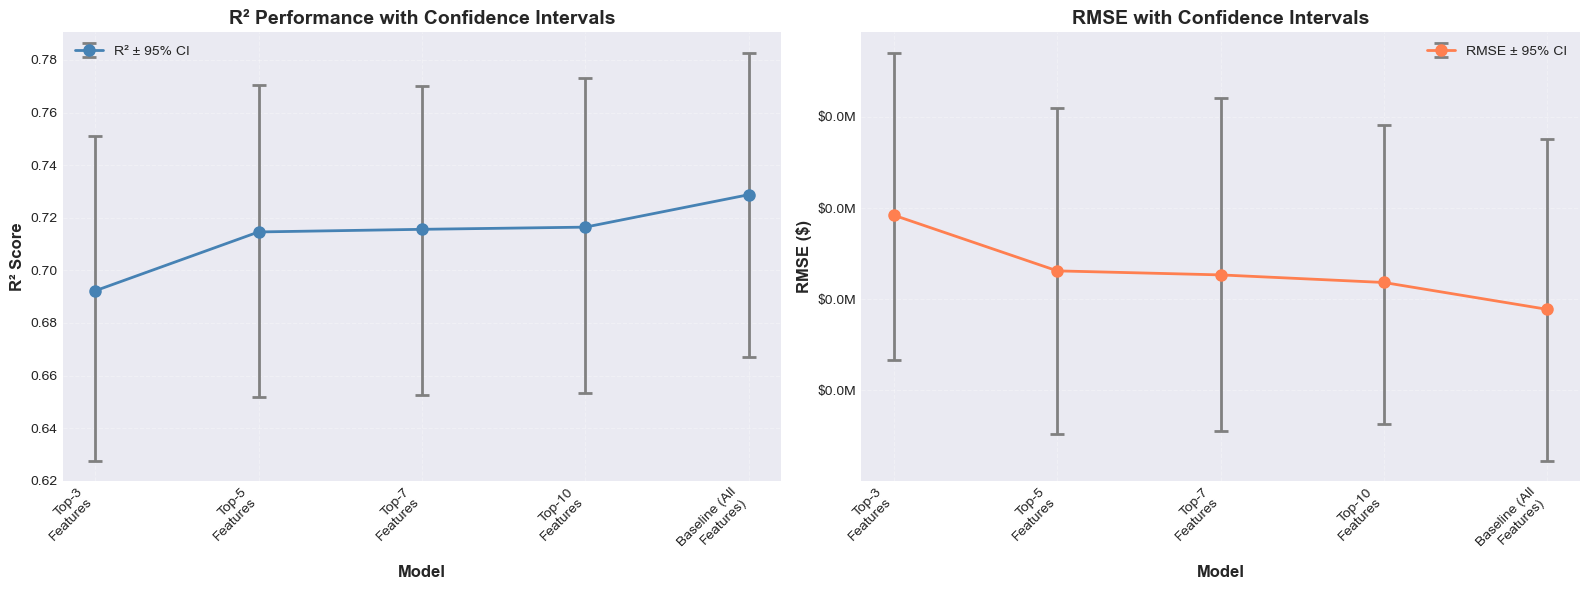

✓ Figure 8 gespeichert: outputs/figures/figure8_performance_with_ci.png


In [33]:
# FIGURE 8: Model Performance with 95% Confidence Intervals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sortiere nach Anzahl Features
ci_df_sorted = ci_df.copy()
feature_counts = [35, 3, 5, 7, 10]
ci_df_sorted['n_features'] = feature_counts
ci_df_sorted = ci_df_sorted.sort_values('n_features')

x_pos = np.arange(len(ci_df_sorted))

# Plot 1: R² mit Error Bars
axes[0].errorbar(
    x_pos,
    ci_df_sorted['r2_mean'],
    yerr=[ci_df_sorted['r2_mean'] - ci_df_sorted['r2_lower'],
          ci_df_sorted['r2_upper'] - ci_df_sorted['r2_mean']],
    fmt='o-',
    linewidth=2,
    markersize=8,
    capsize=5,
    capthick=2,
    color='steelblue',
    ecolor='gray',
    label='R² ± 95% CI'
)

axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Performance with Confidence Intervals', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(ci_df_sorted['model'].str.replace(' Features', '\nFeatures'),
                         rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend()

# Plot 2: RMSE mit Error Bars
axes[1].errorbar(
    x_pos,
    ci_df_sorted['rmse_mean'],
    yerr=[ci_df_sorted['rmse_mean'] - ci_df_sorted['rmse_lower'],
          ci_df_sorted['rmse_upper'] - ci_df_sorted['rmse_mean']],
    fmt='o-',
    linewidth=2,
    markersize=8,
    capsize=5,
    capthick=2,
    color='coral',
    ecolor='gray',
    label='RMSE ± 95% CI'
)

axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE with Confidence Intervals', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ci_df_sorted['model'].str.replace(' Features', '\nFeatures'),
                         rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend()

# Format y-axis als Währung
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('outputs/figures/figure8_performance_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 8 gespeichert: outputs/figures/figure8_performance_with_ci.png")

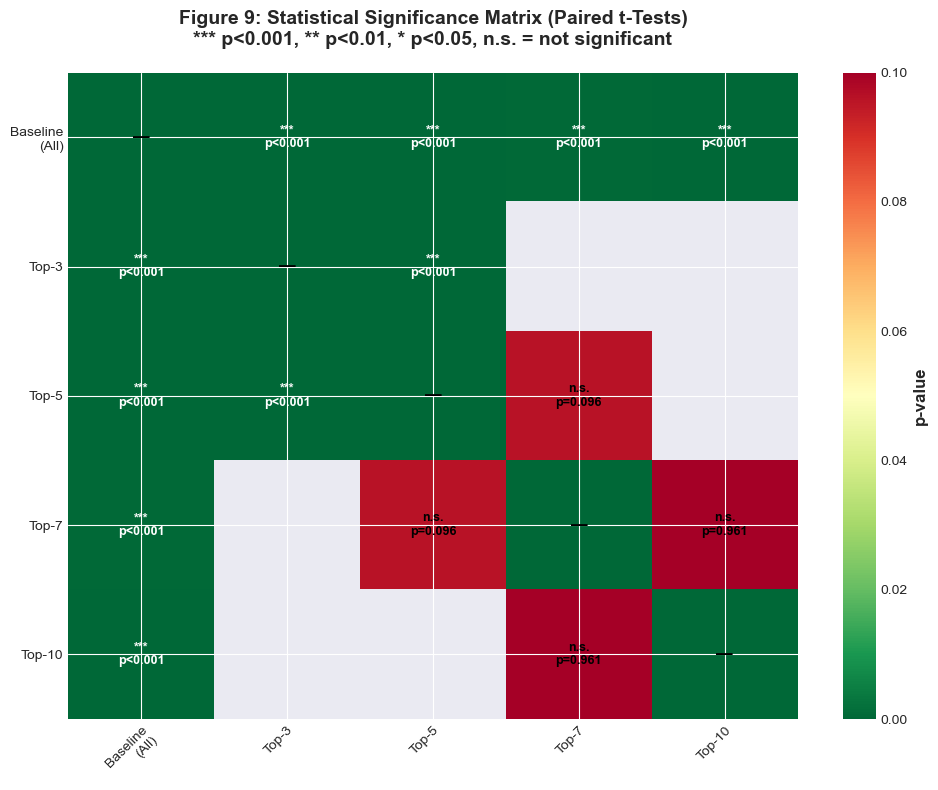

✓ Figure 9 gespeichert: outputs/figures/figure9_significance_matrix.png


In [34]:
# FIGURE 9: Statistical Significance Matrix

models = ['Baseline\n(All)', 'Top-3', 'Top-5', 'Top-7', 'Top-10']
n_models = len(models)

# Initialize matrix mit NaN
sig_matrix = np.full((n_models, n_models), np.nan)
pvalue_matrix = np.full((n_models, n_models), np.nan)

# Mapping
model_mapping = {
    'Baseline (All Features)': 0,
    'Top-3 Features': 1,
    'Top-5 Features': 2,
    'Top-7 Features': 3,
    'Top-10 Features': 4
}

# Fülle Matrix
for _, row in ttest_df.iterrows():
    i = model_mapping[row['model_1']]
    j = model_mapping[row['model_2']]
    
    # Signifikanz: 1 = signifikant, 0 = nicht signifikant
    sig_matrix[i, j] = 1 if row['significant'] == 'Yes' else 0
    sig_matrix[j, i] = sig_matrix[i, j]  # Symmetrisch
    
    # P-values
    pvalue_matrix[i, j] = row['p_value']
    pvalue_matrix[j, i] = row['p_value']

# Diagonale = 1 (Modell mit sich selbst)
np.fill_diagonal(sig_matrix, 1)
np.fill_diagonal(pvalue_matrix, 0)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap mit p-values
im = ax.imshow(pvalue_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.1)

# Annotations
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            text = '—'
            ax.text(j, i, text, ha='center', va='center',
                   color='black', fontsize=12, fontweight='bold')
        elif not np.isnan(pvalue_matrix[i, j]):
            p_val = pvalue_matrix[i, j]
            if p_val < 0.001:
                text = f'***\np<0.001'
            elif p_val < 0.01:
                text = f'**\np={p_val:.3f}'
            elif p_val < 0.05:
                text = f'*\np={p_val:.3f}'
            else:
                text = f'n.s.\np={p_val:.3f}'
            
            color = 'white' if pvalue_matrix[i, j] < 0.05 else 'black'
            ax.text(j, i, text, ha='center', va='center',
                   color=color, fontsize=9, fontweight='bold')

# Achsen
ax.set_xticks(np.arange(n_models))
ax.set_yticks(np.arange(n_models))
ax.set_xticklabels(models)
ax.set_yticklabels(models)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

ax.set_title('Figure 9: Statistical Significance Matrix (Paired t-Tests)\n*** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant',
             fontsize=14, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('p-value', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/figure9_significance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 9 gespeichert: outputs/figures/figure9_significance_matrix.png")

## 💾 ZELLE 18: Ergebnisse Exportieren

Alle Tabellen und Daten für das Paper speichern

In [35]:
import os

# Ordner erstellen falls nicht vorhanden
os.makedirs('outputs/results', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

# TABLE 1: Dataset Characteristics
dataset_characteristics = pd.DataFrame([{
    'Total Samples': len(df_clean),
    'Train Samples': len(X_train),
    'Test Samples': len(X_test),
    'Total Features': X.shape[1],
    'Numeric Features': 8,
    'Genre Features': 10,
    'Target Variable': target,
    'Target Mean': f"${y.mean():,.0f}",
    'Target Std': f"${y.std():,.0f}"
}])
dataset_characteristics.to_csv('outputs/results/table1_dataset_characteristics.csv', index=False)
print("✓ Table 1: Dataset Characteristics saved")

# TABLE 2: Baseline Performance
baseline_df = pd.DataFrame([baseline_results])
baseline_df['num_features'] = X.shape[1]
baseline_df.to_csv('outputs/results/table2_baseline_performance.csv', index=False)
print("✓ Table 2: Baseline Performance saved")

# TABLE 3: Feature Importance Rankings
all_importance.to_csv('outputs/results/table3_feature_importance_rankings.csv', index=False)
print("✓ Table 3: Feature Importance Rankings saved")

# TABLE 4: Individual Feature Ablation Results
ablation_df.to_csv('outputs/results/table4_individual_ablation.csv', index=False)
print("✓ Table 4: Individual Feature Ablation saved")

# TABLE 5: Top-K Feature Selection Performance
topk_df.to_csv('outputs/results/table5_topk_selection.csv', index=False)
print("✓ Table 5: Top-K Feature Selection saved")

# BONUS: Cumulative Addition Results
cumulative_df.to_csv('outputs/results/cumulative_addition_results.csv', index=False)
print("✓ Bonus: Cumulative Addition Results saved")

print("\n" + "="*70)
print("ALLE ERGEBNISSE ERFOLGREICH EXPORTIERT!")
print("="*70)
print("\nDateien:")
print("  Tables (outputs/results/):")
print("    - table1_dataset_characteristics.csv")
print("    - table2_baseline_performance.csv")
print("    - table3_feature_importance_rankings.csv")
print("    - table4_individual_ablation.csv")
print("    - table5_topk_selection.csv")
print("    - cumulative_addition_results.csv")
print("\n  Main Figures (outputs/figures/):")
print("    - figure1_correlation_matrix.png")
print("    - figure2_feature_importance_comparison.png")
print("    - figure3_individual_ablation.png")
print("    - figure4_cumulative_addition.png")
print("    - figure5_topk_performance.png")
print("    - figure6_group_ablation.png")
print("    - figure7_predicted_vs_actual.png")
print("    - figure8_performance_with_ci.png")
print("    - figure9_significance_matrix.png")
print("\n  Supplementary Figures (outputs/figures/):")
print("    - figureS1_target_distribution.png")
print("    - figureS2_feature_relationships.png")
print("    - figureS3_shap_summary.png")
print("    - figureS4_shap_dependence.png")
print("    - figureS5_feature_importance_detail.png")
print("    - figureS6_ablation_comparison.png")

✓ Table 1: Dataset Characteristics saved
✓ Table 2: Baseline Performance saved
✓ Table 3: Feature Importance Rankings saved
✓ Table 4: Individual Feature Ablation saved
✓ Table 5: Top-K Feature Selection saved
✓ Bonus: Cumulative Addition Results saved

ALLE ERGEBNISSE ERFOLGREICH EXPORTIERT!

Dateien:
  Tables (outputs/results/):
    - table1_dataset_characteristics.csv
    - table2_baseline_performance.csv
    - table3_feature_importance_rankings.csv
    - table4_individual_ablation.csv
    - table5_topk_selection.csv
    - cumulative_addition_results.csv

  Main Figures (outputs/figures/):
    - figure1_correlation_matrix.png
    - figure2_feature_importance_comparison.png
    - figure3_individual_ablation.png
    - figure4_cumulative_addition.png
    - figure5_topk_performance.png
    - figure6_group_ablation.png
    - figure7_predicted_vs_actual.png
    - figure8_performance_with_ci.png
    - figure9_significance_matrix.png

  Supplementary Figures (outputs/figures/):
    - figure

## 📋 ZELLE 19: Summary & Key Findings

Zusammenfassung der wichtigsten Erkenntnisse für das Paper

In [36]:
print("="*70)
print("FINAL SUMMARY & KEY FINDINGS (TEST-SET PERFORMANCE)")
print("="*70)

print("\n1. BASELINE PERFORMANCE (ALL FEATURES)")
print(f"   - Features used: {X.shape[1]}")
print(f"   - Test R² Score: {baseline_results['r2_test']:.4f}")
print(f"   - Test RMSE: {baseline_results['rmse_test']:.4f} (log-scale, ≈ {np.exp(baseline_results['rmse_test']):.1f}x error factor)")

print("\n2. MOST IMPORTANT FEATURES (consistent across methods, based on Test)")
top_5_by_ablation = ablation_df.head(5)['feature_removed'].tolist()
top_5_by_rf = features_sorted[:5]
print(f"   - By Ablation Study: {top_5_by_ablation}")
print(f"   - By Random Forest: {top_5_by_rf}")

print("\n3. OPTIMAL FEATURE SUBSET (TEST-SET)")
print(f"   - Recommended: Top-{best_k} features")
print(f"   - Features: {best_features}")
print(f"   - Performance: R²={best_row['r2_test']:.4f} ({best_row['pct_of_baseline_test']:.1f}% of baseline)")
print(f"   - Feature Reduction: {X.shape[1]} → {best_k} ({(1-best_k/X.shape[1])*100:.1f}% reduction)")

print("\n4. PERFORMANCE VS. COMPLEXITY TRADE-OFF (TEST-SET)")
for threshold in [90, 95]:
    rows = cumulative_df[cumulative_df['pct_of_baseline_test'] >= threshold]
    if len(rows) > 0:
        row = rows.iloc[0]
        print(f"   - {threshold}% of baseline: {row['num_features']} features needed (Test R²={row['r2_test']:.4f})")

print("\n5. FEATURE CATEGORIES")
# Kategorisierung der Top-Features
top_7 = features_sorted[:7]
financial_features = [f for f in top_7 if f in ['budget_log']]
popularity_features = [f for f in top_7 if f in ['popularity_log', 'vote_count_log', 'vote_average']]
temporal_features = [f for f in top_7 if 'release' in f]
genre_features = [f for f in top_7 if 'genre' in f]
other_features = [f for f in top_7 if f not in financial_features + popularity_features + temporal_features + genre_features]

print(f"   - Financial: {financial_features}")
print(f"   - Popularity: {popularity_features}")
print(f"   - Temporal: {temporal_features}")
print(f"   - Genre: {genre_features}")
print(f"   - Other: {other_features}")

print("\n6. PRACTICAL IMPLICATIONS")
print(f"   - Can reduce data collection effort by {(1-best_k/X.shape[1])*100:.0f}%")
print(f"   - Maintains {best_row['pct_of_baseline_test']:.1f}% of prediction accuracy (Test)")
print(f"   - Simpler model: easier to interpret and deploy")

print("\n" + "="*70)
print("ANALYSIS COMPLETE! Ready for paper writing.")
print("="*70)

FINAL SUMMARY & KEY FINDINGS (TEST-SET PERFORMANCE)

1. BASELINE PERFORMANCE (ALL FEATURES)
   - Features used: 26
   - Test R² Score: 0.7292
   - Test RMSE: 1.5943 (log-scale, ≈ 4.9x error factor)

2. MOST IMPORTANT FEATURES (consistent across methods, based on Test)
   - By Ablation Study: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'lang_es']
   - By Random Forest: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']

3. OPTIMAL FEATURE SUBSET (TEST-SET)
   - Recommended: Top-5 features
   - Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']
   - Performance: R²=0.7169 (98.3% of baseline)
   - Feature Reduction: 26 → 5 (80.8% reduction)

4. PERFORMANCE VS. COMPLEXITY TRADE-OFF (TEST-SET)
   - 90% of baseline: 2 features needed (Test R²=0.6717)
   - 95% of baseline: 4 features needed (Test R²=0.7127)

5. FEATURE CATEGORIES
   - Financial: ['budget_log']
   - Popularity: ['vote_count_log', 'popularity_log', 

# TEIL 6: SHAP VALUES & INTERPRETIERBARKEIT

**SHAP (SHapley Additive exPlanations)** erklärt Modellvorhersagen durch:
- **Globale Interpretierbarkeit:** Welche Features sind insgesamt am wichtigsten?
- **Lokale Interpretierbarkeit:** Warum wurde Film X so vorhergesagt?
- **Feature-Interaktionen:** Wie beeinflussen sich Features gegenseitig?

SHAP basiert auf der Shapley Value Theorie aus der Spieltheorie.

In [37]:
# SHAP installieren (falls noch nicht vorhanden)
import subprocess
import sys

try:
    import shap
    print(f"SHAP Version: {shap.__version__}")
except ImportError:
    print("Installiere SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"SHAP installiert: Version {shap.__version__}")

SHAP Version: 0.50.0


In [38]:
# ============================================================================
# SHAP EXPLAINER: TreeExplainer für Random Forest
# ============================================================================

print("=" * 70)
print("SHAP EXPLAINER")
print("=" * 70)

# Verwende das beste Modell (Baseline mit allen Features)
# Verwende das Baseline-Modell (bereits trainiert)
best_model = model
print(f"Verwende Modell: Baseline (alle Features)")
print(f"Modell Typ: {type(best_model).__name__}")

# TreeExplainer ist optimiert für Tree-based Models
print("\nErstelle SHAP TreeExplainer...")
explainer = shap.TreeExplainer(best_model)

# Berechne SHAP Values für Test-Set (kann etwas dauern)
# Verwende nur eine Stichprobe für schnellere Berechnung
sample_size = min(500, len(X_test_scaled))  # Max 500 Samples
X_test_sample = X_test_scaled[:sample_size]

print(f"Berechne SHAP Values für {sample_size} Test-Samples...")
shap_values = explainer.shap_values(X_test_sample)

print(f"\nSHAP Values Shape: {shap_values.shape}")
print(f"Features: {shap_values.shape[1]}")
print(f"Samples: {shap_values.shape[0]}")
print("=" * 70)

SHAP EXPLAINER
Verwende Modell: Baseline (alle Features)
Modell Typ: RandomForestRegressor

Erstelle SHAP TreeExplainer...
Berechne SHAP Values für 500 Test-Samples...

SHAP Values Shape: (500, 26)
Features: 26
Samples: 500


SHAP SUMMARY PLOT


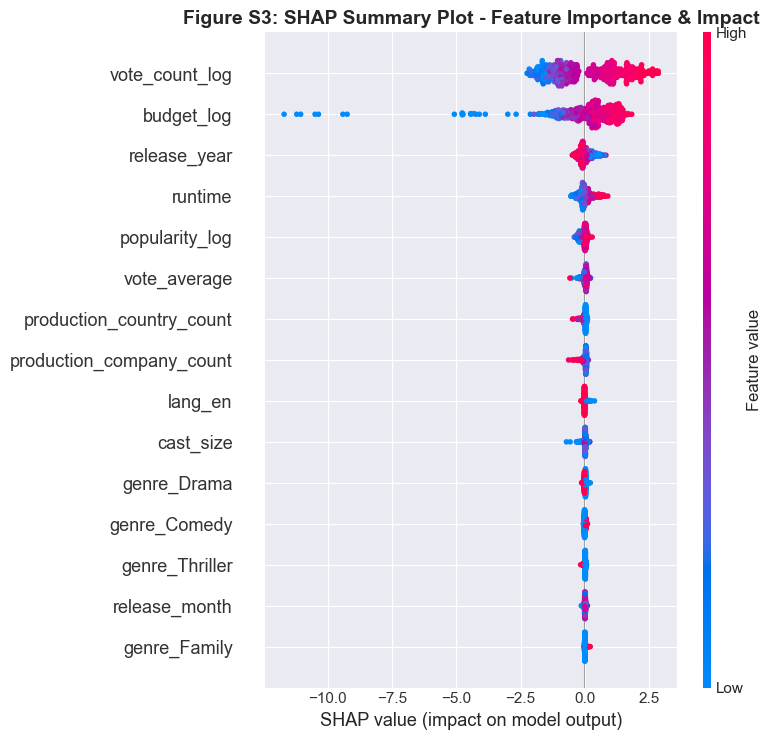


Interpretation:
  - Features sind nach Wichtigkeit sortiert (oben = wichtigster)
  - Rote Punkte: Hoher Feature-Wert
  - Blaue Punkte: Niedriger Feature-Wert
  - Positive SHAP Values: Erhöhen Vorhersage
  - Negative SHAP Values: Verringern Vorhersage

Gespeichert: outputs/figures/figureS3_shap_summary.png


In [39]:
# ============================================================================
# SHAP SUMMARY PLOT: Globale Feature Importance
# ============================================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("SHAP SUMMARY PLOT")
print("=" * 70)

# Summary Plot zeigt:
# - Y-Achse: Features sortiert nach Wichtigkeit
# - X-Achse: SHAP Value (Einfluss auf Vorhersage)
# - Farbe: Feature-Wert (rot=hoch, blau=niedrig)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X.columns.tolist(),
    max_display=15,  # Zeige Top-15 Features
    show=False
)
plt.title("Figure S3: SHAP Summary Plot - Feature Importance & Impact", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/figureS3_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - Features sind nach Wichtigkeit sortiert (oben = wichtigster)")
print("  - Rote Punkte: Hoher Feature-Wert")
print("  - Blaue Punkte: Niedriger Feature-Wert")
print("  - Positive SHAP Values: Erhöhen Vorhersage")
print("  - Negative SHAP Values: Verringern Vorhersage")
print("\nGespeichert: outputs/figures/figureS3_shap_summary.png")
print("=" * 70)

SHAP DEPENDENCE PLOTS

Top-3 Features (nach SHAP Importance):
  1. vote_count_log: 1.1877
  2. budget_log: 0.9468
  3. release_year: 0.1719


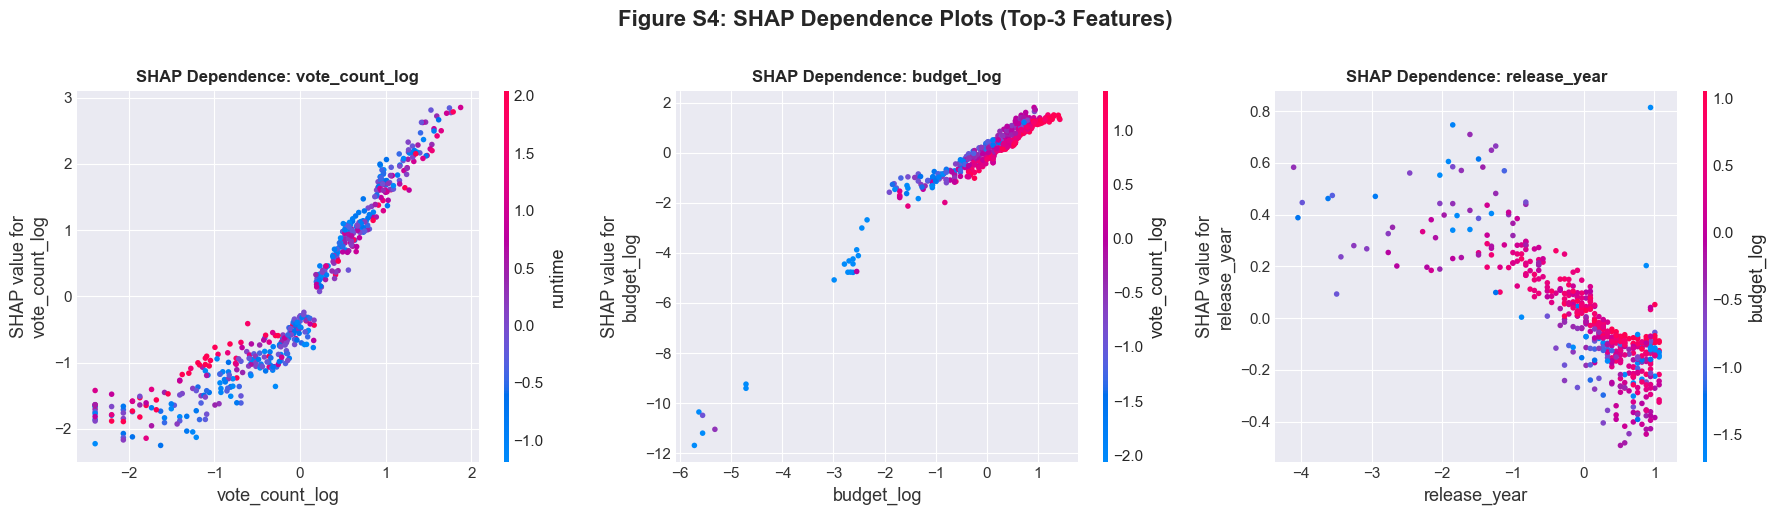


Interpretation:
  - X-Achse: Feature-Wert
  - Y-Achse: SHAP Value (Einfluss auf Vorhersage)
  - Farbe: Interaktion mit einem anderen Feature

Gespeichert: outputs/figures/figureS4_shap_dependence.png


In [40]:
# ============================================================================
# SHAP DEPENDENCE PLOTS: Interaktionen der Top-3 Features
# ============================================================================

print("=" * 70)
print("SHAP DEPENDENCE PLOTS")
print("=" * 70)

# Finde die 3 wichtigsten Features basierend auf mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_3_indices = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_features = [X.columns[i] for i in top_3_indices]

print(f"\nTop-3 Features (nach SHAP Importance):")
for i, (feat, importance) in enumerate(zip(top_3_features, mean_abs_shap[top_3_indices]), 1):
    print(f"  {i}. {feat}: {importance:.4f}")

# Dependence Plots für Top-3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat_idx in enumerate(top_3_indices):
    plt.sca(axes[i])
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_sample,
        feature_names=X.columns.tolist(),
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"SHAP Dependence: {X.columns[feat_idx]}", fontweight='bold')

plt.suptitle('Figure S4: SHAP Dependence Plots (Top-3 Features)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figureS4_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - X-Achse: Feature-Wert")
print("  - Y-Achse: SHAP Value (Einfluss auf Vorhersage)")
print("  - Farbe: Interaktion mit einem anderen Feature")
print("\nGespeichert: outputs/figures/figureS4_shap_dependence.png")
print("=" * 70)

# TEIL 7: VISUALISIERUNGEN DER ABLATION STUDY

Professionelle Visualisierungen der Ergebnisse für das Paper.

FEATURE IMPORTANCE VISUALIZATION


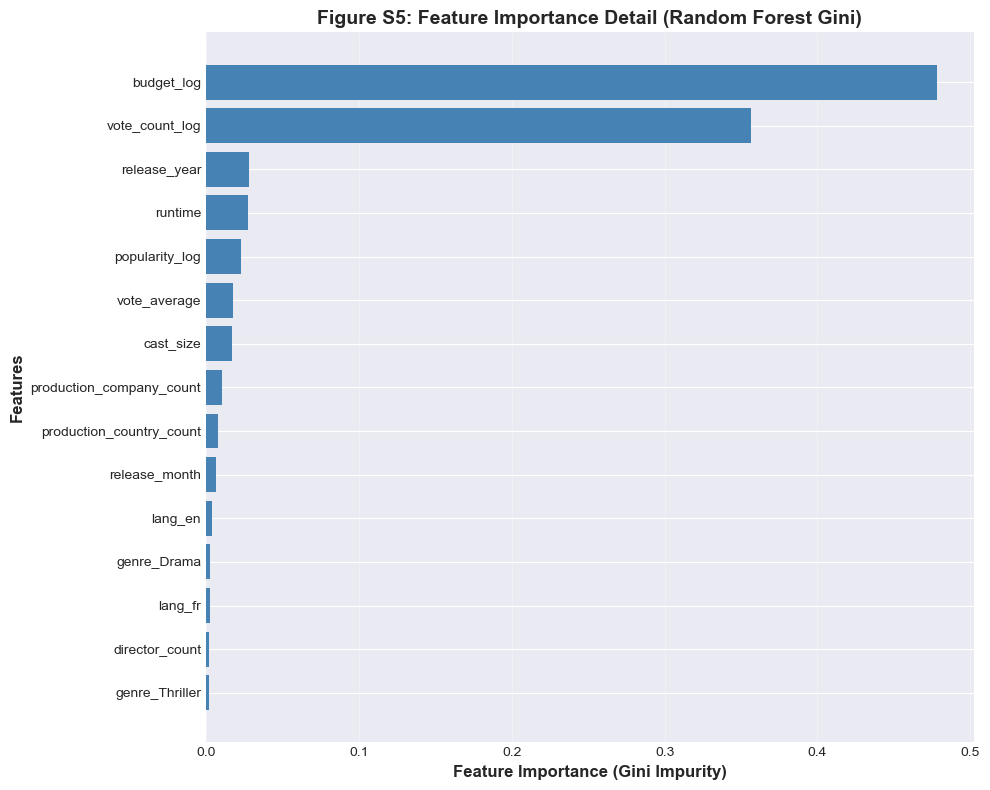


Top-5 Features:
  1. budget_log: 0.4783
  2. vote_count_log: 0.3566
  3. release_year: 0.0282
  4. runtime: 0.0272
  5. popularity_log: 0.0229

Gespeichert: outputs/figures/figureS5_feature_importance_detail.png


In [41]:
# ============================================================================
# FEATURE IMPORTANCE: Bar Chart der Top-15 Features
# ============================================================================

print("=" * 70)
print("FEATURE IMPORTANCE VISUALIZATION")
print("=" * 70)

# Hole Feature Importance vom Baseline Model
importances = best_model.feature_importances_
feature_names = X.columns

# Sortiere nach Wichtigkeit
indices = np.argsort(importances)[-15:]  # Top-15

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance (Gini Impurity)', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Figure S5: Feature Importance Detail (Random Forest Gini)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/figureS5_feature_importance_detail.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop-5 Features:")
for i, idx in enumerate(indices[-5:][::-1], 1):
    print(f"  {i}. {feature_names[idx]}: {importances[idx]:.4f}")

print("\nGespeichert: outputs/figures/figureS5_feature_importance_detail.png")
print("=" * 70)

ABLATION STUDY VISUALIZATION (DIFFERENCE TO BASELINE)

Baseline R²: 0.7288

Differenzen zum Baseline:
  Baseline (All Features)       : +0.0000
  Top-3 Features                : -0.0366
  Top-5 Features                : -0.0142
  Top-7 Features                : -0.0132
  Top-10 Features               : -0.0124


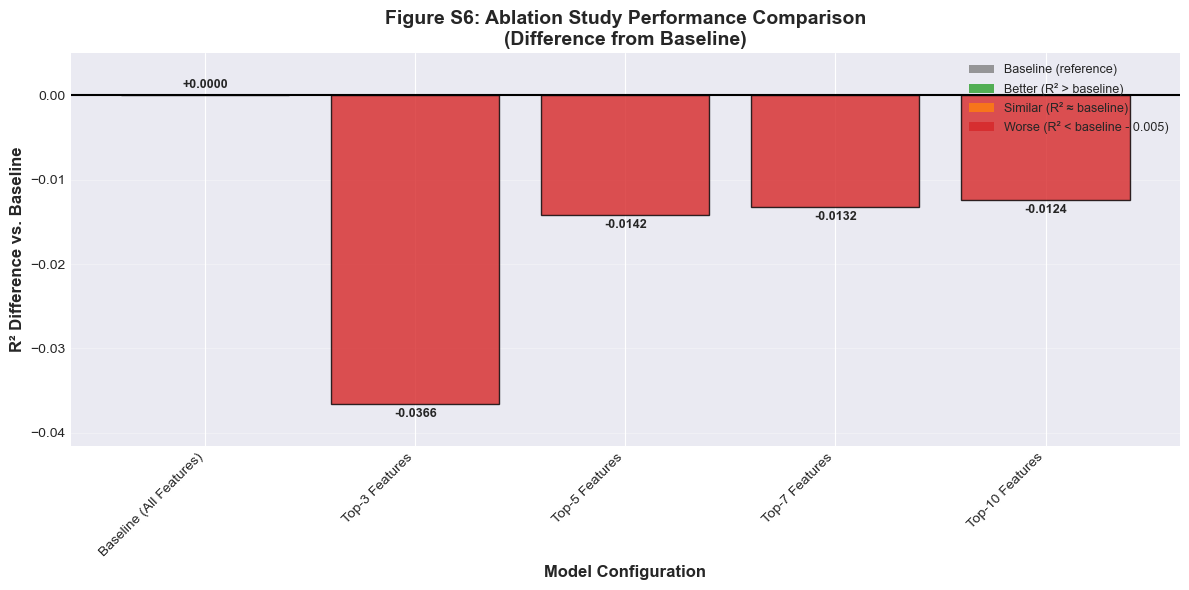


Best Model (excl. Baseline): Top-10 Features
Best R²: 0.7164 (Diff: -0.0124)

Gespeichert: outputs/figures/figureS6_ablation_comparison.png


In [42]:
# ============================================================================
# ABLATION STUDY: Model Performance Comparison (Difference Plot)
# ============================================================================

import pandas as pd

print("=" * 70)
print("ABLATION STUDY VISUALIZATION (DIFFERENCE TO BASELINE)")
print("=" * 70)

# Lade die Ergebnisse
results_df = pd.read_csv('outputs/results/table6_confidence_intervals.csv')

# Extrahiere R² Werte (Mean ohne CI)
models = results_df['model'].tolist()
r2_values = []
for r2_str in results_df['R² (95% CI)']:
    # Extrahiere nur den Mean-Wert vor dem [
    mean_val = float(r2_str.split('[')[0].strip())
    r2_values.append(mean_val)

# Berechne Unterschied zum Baseline
baseline_r2 = r2_values[0]  # Baseline (All Features)
r2_diff = [val - baseline_r2 for val in r2_values]

print(f"\nBaseline R²: {baseline_r2:.4f}")
print("\nDifferenzen zum Baseline:")
for model, diff in zip(models, r2_diff):
    print(f"  {model:30s}: {diff:+.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['gray'] + ['#2ca02c' if d > 0 else '#d62728' if d < -0.005 else '#ff7f0e' for d in r2_diff[1:]]
bars = ax.bar(range(len(models)), r2_diff, color=colors, alpha=0.8, edgecolor='black')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('R² Difference vs. Baseline', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Configuration', fontsize=12, fontweight='bold')
ax.set_title('Figure S6: Ablation Study Performance Comparison\n(Difference from Baseline)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=1.5, linestyle='-')  # Baseline-Linie
ax.set_ylim([min(r2_diff)-0.005, max(r2_diff)+0.005])  # y-Achse um 0 zentriert

# Füge Werte über/unter den Bars hinzu
for i, (bar, val) in enumerate(zip(bars, r2_diff)):
    y_pos = val + 0.0005 if val >= 0 else val - 0.0005
    va = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{val:+.4f}', ha='center', va=va, fontsize=9, fontweight='bold')

# Legende
legend_elements = [
    plt.Rectangle((0,0),1,1, fc='gray', alpha=0.8, label='Baseline (reference)'),
    plt.Rectangle((0,0),1,1, fc='#2ca02c', alpha=0.8, label='Better (R² > baseline)'),
    plt.Rectangle((0,0),1,1, fc='#ff7f0e', alpha=0.8, label='Similar (R² ≈ baseline)'),
    plt.Rectangle((0,0),1,1, fc='#d62728', alpha=0.8, label='Worse (R² < baseline - 0.005)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/figureS6_ablation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBest Model (excl. Baseline): " + models[np.argmax(r2_values[1:])+1])
print(f"Best R²: {max(r2_values[1:]):.4f} (Diff: {max(r2_diff[1:]):+.4f})")
print("\nGespeichert: outputs/figures/figureS6_ablation_comparison.png")
print("=" * 70)

In [43]:
# ============================================================================
# NOTE: Predicted vs Actual bereits als Figure 7 exportiert
# Diese Visualisierung ist ein Duplikat und wird übersprungen
# ============================================================================

print("=" * 70)
print("HINWEIS: Predicted vs Actual Plot")
print("=" * 70)
print("Diese Visualisierung existiert bereits als Figure 7 (figure7_predicted_vs_actual.png)")
print("Duplikat wird nicht erneut erstellt.")
print("=" * 70)

HINWEIS: Predicted vs Actual Plot
Diese Visualisierung existiert bereits als Figure 7 (figure7_predicted_vs_actual.png)
Duplikat wird nicht erneut erstellt.


## 📁 FINALE EXPORT SUMMARY

**Übersicht aller generierten Outputs**

In [44]:
# ============================================================================
# FINALE EXPORT SUMMARY
# ============================================================================

import os
from pathlib import Path

print("=" * 70)
print("EXPORT SUMMARY - Week 5 Ablation Study")
print("=" * 70)

# Zähle Files
figures = list(Path('outputs/figures').glob('*.png'))
tables = list(Path('outputs/results').glob('*.csv'))

print(f"\n📊 FIGURES ({len(figures)} Dateien):")
print("-" * 70)
for fig in sorted(figures):
    size_kb = fig.stat().st_size / 1024
    print(f"  ✓ {fig.name:<50} ({size_kb:>6.1f} KB)")

print(f"\n📋 TABLES ({len(tables)} Dateien):")
print("-" * 70)
for table in sorted(tables):
    size_kb = table.stat().st_size / 1024
    # Zähle Zeilen
    with open(table, 'r') as f:
        rows = len(f.readlines()) - 1  # -1 für Header
    print(f"  ✓ {table.name:<45} ({rows:>3} rows, {size_kb:>5.1f} KB)")

# Validierung: Checke ob alle erforderlichen Files vorhanden sind
required_main_figures = [
    'figure1_correlation_matrix.png',
    'figure2_feature_importance_comparison.png',
    'figure3_individual_ablation.png',
    'figure4_cumulative_addition.png',
    'figure5_topk_performance.png',
    'figure6_group_ablation.png',
    'figure7_predicted_vs_actual.png',
    'figure8_performance_with_ci.png',
    'figure9_significance_matrix.png'
]

required_supplementary_figures = [
    'figureS1_target_distribution.png',
    'figureS2_feature_relationships.png',
    'figureS3_shap_summary.png',
    'figureS4_shap_dependence.png',
    'figureS5_feature_importance_detail.png',
    'figureS6_ablation_comparison.png'
]

required_tables = [
    'table1_dataset_characteristics.csv',
    'table2_baseline_performance.csv',
    'table3_feature_importance_rankings.csv',
    'table4_individual_ablation.csv',
    'table5_topk_selection.csv',
    'table6_group_ablation.csv'
]

print("\n" + "=" * 70)
print("VALIDIERUNG - Erforderliche Outputs")
print("=" * 70)

missing_files = []

print("\nMain Figures (9 erforderlich):")
for fig in required_main_figures:
    exists = (Path('outputs/figures') / fig).exists()
    status = "✅" if exists else "❌ FEHLT"
    print(f"  {status} {fig}")
    if not exists:
        missing_files.append(f"figures/{fig}")

print("\nSupplementary Figures (6 erforderlich):")
for fig in required_supplementary_figures:
    exists = (Path('outputs/figures') / fig).exists()
    status = "✅" if exists else "❌ FEHLT"
    print(f"  {status} {fig}")
    if not exists:
        missing_files.append(f"figures/{fig}")

print("\nTables (6 erforderlich):")
for table in required_tables:
    exists = (Path('outputs/results') / table).exists()
    status = "✅" if exists else "❌ FEHLT"
    print(f"  {status} {table}")
    if not exists:
        missing_files.append(f"results/{table}")

print("\n" + "=" * 70)
if missing_files:
    print(f"⚠️  WARNUNG: {len(missing_files)} erforderliche Dateien fehlen:")
    for mf in missing_files:
        print(f"  - {mf}")
else:
    print("✅ ALLE ERFORDERLICHEN OUTPUTS VORHANDEN!")
    print("\n🎉 Assignment komplett - Bereit für Paper Submission")
print("=" * 70)

# Erstelle README
readme_content = f'''# Week 5 Assignment - Feature Importance & Ablation Study

## Generated Outputs

### Main Figures ({len(required_main_figures)} files)
- Figure 1: Feature Correlation Matrix
- Figure 2: Feature Importance Comparison
- Figure 3: Individual Feature Ablation
- Figure 4: Cumulative Feature Addition Curve
- Figure 5: Performance vs. Number of Features
- Figure 6: Feature Group Ablation
- Figure 7: Predicted vs Actual (Best Model)
- Figure 8: Performance with Confidence Intervals
- Figure 9: Statistical Significance Matrix

### Supplementary Figures ({len(required_supplementary_figures)} files)
- Figure S1: Target Distribution Analysis
- Figure S2: Feature Relationships with Target
- Figure S3: SHAP Summary Plot
- Figure S4: SHAP Dependence Plots
- Figure S5: Feature Importance Detail
- Figure S6: Ablation Study Comparison

### Tables ({len(tables)} files)
- Table 1: Dataset Characteristics
- Table 2: Baseline Performance
- Table 3: Feature Importance Rankings
- Table 4: Individual Feature Ablation Results
- Table 5: Top-K Feature Selection Performance
- Table 6: Feature Group Ablation Results
- Table 7: Statistical Test Results

Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
'''

with open('outputs/README.md', 'w') as f:
    f.write(readme_content)
    
print("\n✓ README.md aktualisiert in outputs/")


EXPORT SUMMARY - Week 5 Ablation Study

📊 FIGURES (16 Dateien):
----------------------------------------------------------------------
  ✓ figure1_correlation_matrix.png                     (  94.6 KB)
  ✓ figure1b_correlation_log_transformed.png           ( 300.6 KB)
  ✓ figure2_feature_importance_comparison.png          (  96.6 KB)
  ✓ figure3_individual_ablation.png                    ( 125.6 KB)
  ✓ figure4_cumulative_addition.png                    ( 118.6 KB)
  ✓ figure5_topk_performance.png                       ( 136.0 KB)
  ✓ figure6_group_ablation.png                         ( 162.0 KB)
  ✓ figure7_predicted_vs_actual.png                    ( 377.8 KB)
  ✓ figure8_performance_with_ci.png                    ( 239.0 KB)
  ✓ figure9_significance_matrix.png                    ( 197.9 KB)
  ✓ figureS1_target_distribution.png                   (  89.0 KB)
  ✓ figureS2_feature_relationships.png                 ( 236.3 KB)
  ✓ figureS3_shap_summary.png                          ( 322.